<a href="https://colab.research.google.com/github/YH-MAX/WIA2005/blob/main/WIA2005_Cypher_Nexus_Stealth_Survival(Ghost_Battery).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WIA2005 Algorithm Analysis and Design Group Project

## Mission Aim: Stealth Survival

Our group selected **Stealth Survival** as the mission aim.  
In this mission direction, the team does not simply aim to move the fastest, cause the largest disruption, or choose the most obvious optimal action. Instead, the main goal is to survive by staying hidden from **Cypher Nexus** for as long as possible.

The team must make decisions that reduce detection risk, avoid unnecessary exposure, and prevent Cypher Nexus from predicting or locking on to their movements.

---

## Unique Constraint: Ghost-Battery Protocol

## Overall Ghost-Battery Design Rule

This notebook follows the same uniqueness rule used in our Week 11 presentation.

Our solution is not only evaluated by correctness or Big-O time complexity.  
Each selected algorithm must also reduce:

- repeated processing
- battery drain
- thermal / alert exposure
- predictable movement or search patterns

Therefore, standard textbook algorithms are adapted into Ghost-Battery-aware algorithms.

Across Parts 1–8, the selected algorithms are modified as follows:

| Part | Ghost-Battery Modification |
|---|---|
| Part 1 | Standard Dijkstra is extended with state tracking: (node, previousEdgeMonitored) |
| Part 2 | Duplicate detection is restricted to one registry sweep using hashing |
| Part 3 | Basic knapsack is extended with silent override tokens using dp[i][b][t] |
| Part 4 | Routes above the alert threshold are rejected before scoring |
| Part 5 | Invalid fragments are filtered before sorting |
| Part 6 | Only top-k urgent threats are maintained |
| Part 7 | Predicted danger zones are filtered before weighted randomness |
| Part 8 | All trigger phrases are compiled into one automaton and scanned once |

### Concept

Our group introduces **Ghost-Battery Protocol** as the unique constraint for the mission.

The team carries a special **Ghost-Battery** that can temporarily hide their digital and physical traces from Cypher Nexus. However, the battery charge is extremely limited.

Every major action consumes Ghost-Battery charge, including:

- Route traversal
- Data scanning
- Searching
- Sorting
- Signal decoding
- Resource optimisation
- Randomised movement
- Registry verification
- Pattern detection

If the team overuses the Ghost-Battery, the system becomes unstable. This causes:

- Thermal signature increase
- Detection probability increase
- Higher alert exposure
- Greater chance of Cypher Nexus lock-on

Therefore, all algorithmic decisions must complete the mission under two main priorities:

1. **Low battery consumption**
2. **Low exposure risk**

---

## Formal Definition

**Ghost-Battery Protocol** is a stealth-first resource constraint where every algorithmic and tactical operation consumes limited battery charge. The battery helps hide the team’s traces, but excessive usage increases thermal signature and detection probability.

As a result, our team does not evaluate algorithms only by traditional criteria such as shortest path, fastest runtime, or highest impact. Instead, each algorithm must balance mission effectiveness with low energy consumption and low detection exposure.

A solution is considered better only if it provides strong mission value while keeping the team hidden and conserving battery power.

---

## How Ghost-Battery Protocol Affects Our Algorithm Choices

| Normal Strategy | Ghost-Battery Strategy |
|---|---|
| Choose the shortest route | Choose the safest stealth-adjusted route |
| Search the whole dataset repeatedly | Build indexes to reduce repeated scans |
| Select the highest-impact target | Select the best impact with acceptable battery cost and exposure |
| Always choose the obvious optimal move | Avoid predictable decisions when necessary |
| Maximise disruption aggressively | Perform silent and controlled disruption |
| Process all data at once | Process only necessary data efficiently |

## Main Decision Rule

Our team uses the following decision rule throughout Parts 1–8:

```text
Best solution = High mission value + Low battery consumption + Low detection exposure

# Part 1: The Shadow Network

## 1. Mission Problem

In Part 1, the team receives the clue **“Follow the harbour network.”**
After reaching the abandoned Port Authority Hub, the team discovers that the harbour district is connected through many locations, such as warehouses, relay towers, dockyard gates, cargo tunnels, safe houses, and encrypted communication points.

These locations form a harbour network. The team must analyse this structure and find a safe route from the starting point to the target location without triggering Cypher Nexus.

However, the safest route is not necessarily the shortest route. Some routes may be short but monitored, while other routes may be longer but safer.

Therefore, the route decision must prioritise stealth before distance.

---

## 2. Unique Constraint: Ghost-Battery Protocol

Our group uses **Ghost-Battery Protocol** as the unique constraint under the **Stealth Survival** mission aim.

The team carries a limited Ghost-Battery that can temporarily hide movement traces and reduce detection by Cypher Nexus. However, every route traversal may increase alert exposure, especially when the team passes through monitored edges.

For Part 1, the Ghost-Battery rule is:

```text
Minimise monitored-edge exposure first, then total distance.
Consecutive monitored edges are not allowed.
```

This means the algorithm must not optimise physical distance only. It must avoid routes that create repeated monitored exposure.

---

## 3. Computational Problem Interpretation

This problem is modelled as a **state-aware weighted graph pathfinding problem**.

| Mission Element                | Graph Representation         |
| ------------------------------ | ---------------------------- |
| Harbour locations              | Nodes / vertices             |
| Routes between locations       | Directed edges               |
| Distance between locations     | Edge distance                |
| Monitored route label          | Alert exposure indicator     |
| Starting location              | Source node                  |
| Target location                | Destination node             |
| Previous monitored-edge status | Additional state information |

The algorithmic task is:

> Given a directed weighted graph, find a route from the start node to the target node that minimises monitored-edge exposure first and total distance second, while avoiding consecutive monitored edges.

This follows the latest Ghost-Battery uniqueness rule:

* Standard Dijkstra is modified with state tracking: `(node, previousEdgeMonitored)`
* The priority queue compares `(alertActivations, totalDistance)`
* Any transition that creates two consecutive monitored edges is rejected

---

## 4. Input and Output

### Input

The dataset contains route information such as:

* From node
* To node
* Distance
* Travel time
* Risk level
* Detection probability
* Route status

### Output

The program should produce:

* Best stealth-safe route
* Total monitored-edge alert activations
* Total distance
* Selected route details
* Confirmation that consecutive monitored edges are avoided

---

## 5. Assumptions

The following assumptions are used for Part 1:

1. The harbour network is treated as a directed graph.
2. All edge distances are non-negative.
3. A monitored route increases alert exposure.
4. Two consecutive monitored edges are not allowed.
5. The best route is selected by lowest alert exposure first, then lowest total distance.
6. BFS and standard Dijkstra are used as comparison baselines, not as the final solution.

---

## 6. Candidate Algorithms

### Candidate 1: Breadth-First Search — Rejected

#### Idea

Breadth-First Search explores the graph level by level. It can find a path with the fewest number of edges from the start node to the target node.

#### Pseudocode

```text
BFS(graph, start, target):
    create a queue
    add start to queue
    mark start as visited

    while queue is not empty:
        current = remove front of queue

        if current == target:
            return path

        for each neighbour of current:
            if neighbour is not visited:
                mark neighbour as visited
                store previous node
                add neighbour to queue

    return no path found
```

#### Time and Space Complexity

| Complexity Type  | Complexity |
| ---------------- | ---------- |
| Time Complexity  | O(V + E)   |
| Space Complexity | O(V)       |

#### Advantages

* Simple to implement.
* Works well for unweighted graphs.
* Quickly finds a route with the fewest number of edges.

#### Limitations

* It ignores distance.
* It ignores monitored-edge labels.
* It may choose a route with fewer stops but higher alert exposure.

#### Decision

BFS is rejected because the Ghost-Battery mission objective is not the fewest stops. The route must minimise monitored-edge exposure first.

---

### Candidate 2: Standard Dijkstra — Rejected

#### Idea

Standard Dijkstra finds the shortest total distance in a weighted graph with non-negative edge weights.

#### Pseudocode

```text
Dijkstra(graph, start):
    set distance of all nodes to infinity
    set distance of start node to 0
    create a priority queue
    insert start node into priority queue

    while priority queue is not empty:
        current_node = node with lowest distance

        for each edge from current_node:
            new_distance = distance[current_node] + edge_distance

            if new_distance is lower than previous known distance:
                update distance
                store previous node
                push neighbour into priority queue

    return shortest path
```

#### Time and Space Complexity

| Complexity Type  | Complexity       |
| ---------------- | ---------------- |
| Time Complexity  | O((V + E) log V) |
| Space Complexity | O(V)             |

#### Advantages

* Suitable for weighted graphs.
* Finds the shortest-distance route.
* Uses a priority queue efficiently.

#### Limitations

* It optimises distance only.
* It does not remember whether the previous edge was monitored.
* It may choose two consecutive monitored edges.

#### Decision

Standard Dijkstra is rejected because the shortest-distance route may still violate the Ghost-Battery rule against consecutive monitored edges.

---

### Candidate 3: Ghost-Battery-Aware Dijkstra — Selected

#### Idea

Ghost-Battery-Aware Dijkstra modifies standard Dijkstra by adding state tracking.

Instead of tracking only the current node, the algorithm tracks:

```text
state = (node, previousEdgeMonitored)
```

The priority queue compares routes using:

```text
priority = (alertActivations, totalDistance)
```

This means the algorithm minimises monitored-edge exposure first. If two routes have the same alert exposure, it chooses the shorter total distance.

#### Pseudocode

```text
GhostBatteryDijkstra(graph, start, target):
    push (alert=0, distance=0, start, previousMonitored=false) into priority queue

    while priority queue is not empty:
        pop state with lowest alert, then lowest distance

        for each edge from current node:
            if previous edge is monitored and current edge is monitored:
                skip this transition

            newAlert = current alert + monitored edge indicator
            newDistance = current distance + edge distance
            newState = (next node, current edge monitored)

            if newState improves previous best priority:
                update best state
                store previous state
                push newState into priority queue

    return safest valid path
```

#### Time and Space Complexity

| Complexity Type  | Complexity       |
| ---------------- | ---------------- |
| Time Complexity  | O((V + E) log V) |
| Space Complexity | O(V)             |

Although each node can have two monitored states, this only adds a constant factor. Therefore, the complexity remains comparable to standard Dijkstra.

#### Advantages

* Suitable for weighted graphs.
* Minimises alert exposure before distance.
* Rejects consecutive monitored edges.
* Directly matches the Ghost-Battery Protocol.

#### Limitations

* Slightly more complex than standard Dijkstra because it stores state.
* Requires route status labels to identify monitored edges.

#### Decision

Ghost-Battery-Aware Dijkstra is selected because it makes the route decision stealth-aware instead of distance-only.

---

## 7. Complexity Comparison

| Algorithm                    |  Time Complexity | Space Complexity | Strength                       | Weakness                              |
| ---------------------------- | ---------------: | ---------------: | ------------------------------ | ------------------------------------- |
| Breadth-First Search         |         O(V + E) |             O(V) | Simple baseline                | Ignores weights and monitored risk    |
| Standard Dijkstra            | O((V + E) log V) |             O(V) | Finds shortest weighted route  | Ignores previous monitored-edge state |
| Ghost-Battery-Aware Dijkstra | O((V + E) log V) |             O(V) | Minimises alert exposure first | Requires additional state tracking    |

---

## 8. Rejected Approaches

The rejected approaches are **Breadth-First Search** and **Standard Dijkstra**.

BFS is rejected because it only finds the route with the fewest stops. It does not consider distance or monitored-edge exposure.

Standard Dijkstra is rejected because it minimises total distance only. It does not track whether the previous edge was monitored, so it may choose two consecutive monitored edges.

Under the Ghost-Battery Protocol, both approaches are incomplete because they do not fully model stealth exposure.

---

## 9. Chosen Solution

The chosen solution for Part 1 is:

```text
Ghost-Battery-Aware Dijkstra with State Tracking
```

The selected algorithm modifies standard Dijkstra with the state:

```text
(node, previousEdgeMonitored)
```

The priority queue compares:

```text
(alertActivations, totalDistance)
```

This allows the algorithm to choose the route with the lowest monitored-edge exposure first and the shortest distance second.

---

## 10. Final Justification

Ghost-Battery-Aware Dijkstra is the most suitable algorithm for Part 1 because the problem is not a normal shortest-path problem.

A normal shortest-path algorithm may choose a route that is physically short but stealth-unsafe. By tracking whether the previous edge was monitored, the selected algorithm can reject consecutive monitored routes and choose the safest valid harbour path.

Therefore, the selected solution supports the Ghost-Battery Protocol by reducing alert exposure, avoiding predictable monitored movement, and still considering total distance as a secondary objective.

---

## 11. Implementation Plan

The Python implementation follows these steps:

1. Load the Part 1 Excel dataset.
2. Read the assigned sheet.
3. Build a directed graph using route distance and route status.
4. Define monitored-edge labels.
5. Run Ghost-Battery-Aware Dijkstra.
6. Track state as `(node, previousEdgeMonitored)`.
7. Reject transitions with consecutive monitored edges.
8. Reconstruct the safest valid route.
9. Display total alert activations, total distance, and route details.

The next code cell implements this selected algorithm.


In [ ]:
# ============================================================
# WIA2005 Group Project
# Part 1: The Shadow Network
# Chosen Algorithm: Ghost-Battery-Aware Dijkstra with State Tracking
# Unique Constraint: Ghost-Battery Protocol
#
# Core idea:
# - State = (node, previousEdgeMonitored)
# - Priority = (alertActivations, totalDistance)
# - Consecutive monitored edges are not allowed
# ============================================================

import pandas as pd
import heapq
import math
from collections import defaultdict
from IPython.display import display

# ============================================================
# 1. Load and Clean Dataset B
# ============================================================

FILE_PATH = "/content/Part 1.xlsx"
SHEET_NAME = "B"

raw_df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, header=None)

expected_columns = [
    "From_Node",
    "To_Node",
    "Distance",
    "Travel_Time",
    "Risk_Level",
    "Detection_Probability",
    "Route_Status"
]

header_row = None

for i in range(min(10, len(raw_df))):
    row_values = raw_df.iloc[i].astype(str).str.strip().tolist()
    matched = sum(col in row_values for col in expected_columns)

    if matched >= 4:
        header_row = i
        break

if header_row is None:
    raise ValueError(
        "Could not find the dataset header row. "
        "Please check the Excel file format."
    )

df_part1 = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, header=header_row)

df_part1.columns = df_part1.columns.astype(str).str.strip()

df_part1 = df_part1[expected_columns].copy()
df_part1 = df_part1.dropna(how="all")

df_part1["From_Node"] = df_part1["From_Node"].astype(str).str.strip()
df_part1["To_Node"] = df_part1["To_Node"].astype(str).str.strip()
df_part1["Route_Status"] = df_part1["Route_Status"].astype(str).str.strip()

numeric_columns = [
    "Distance",
    "Travel_Time",
    "Risk_Level",
    "Detection_Probability"
]

for col in numeric_columns:
    df_part1[col] = pd.to_numeric(df_part1[col], errors="coerce")

df_part1 = df_part1.dropna(subset=expected_columns).copy()

print("Part 1 Dataset Loaded Successfully")
print("==================================")
print(f"Using sheet: {SHEET_NAME}")
print()
print("Columns:")
print(df_part1.columns.tolist())
print()
display(df_part1)

Part 1 Dataset Loaded Successfully
Using sheet: B

Columns:
['From_Node', 'To_Node', 'Distance', 'Travel_Time', 'Risk_Level', 'Detection_Probability', 'Route_Status']



,From_Node,To_Node,Distance,Travel_Time,Risk_Level,Detection_Probability,Route_Status
0,Port Authority Hub,Pier Gate North,4.0,5.0,3.0,0.09,Open
1,Port Authority Hub,Signal Mast South,7.0,5.0,7.0,0.30,Monitored
2,Pier Gate North,Cargo Scan Lane,5.0,6.0,4.0,0.12,Open
3,Cargo Scan Lane,Warehouse Delta,4.0,7.0,5.0,0.18,Open
4,Warehouse Delta,Financial Vault Access,5.0,6.0,4.0,0.15,Open
5,Signal Mast South,Financial Vault Access,6.0,4.0,8.0,0.36,Restricted
6,Pier Gate North,Safe House Kilo,6.0,8.0,2.0,0.07,Open
7,Safe House Kilo,Archive Lift,4.0,5.0,3.0,0.09,Open
8,Archive Lift,Financial Vault Access,6.0,7.0,3.0,0.11,Open
9,Cargo Scan Lane,Flood Barrier East,3.0,5.0,6.0,0.21,Monitored


In [ ]:
# ============================================================
# 2. Build Directed Harbour Graph
# ============================================================

graph = defaultdict(list)

for _, row in df_part1.iterrows():
    from_node = row["From_Node"]
    to_node = row["To_Node"]

    edge = {
        "to": to_node,
        "distance": float(row["Distance"]),
        "travel_time": float(row["Travel_Time"]),
        "risk_level": float(row["Risk_Level"]),
        "detection_probability": float(row["Detection_Probability"]),
        "route_status": row["Route_Status"]
    }

    graph[from_node].append(edge)

    # Ensure destination node also exists in graph
    if to_node not in graph:
        graph[to_node] = []

print("Directed graph built successfully.")
print("Number of nodes:", len(graph))
print("Number of edges:", sum(len(edges) for edges in graph.values()))

available_nodes = sorted(graph.keys())

print("\nAvailable nodes:")
for node in available_nodes:
    print("-", node)

Directed graph built successfully.
Number of nodes: 9
Number of edges: 13

Available nodes:
- Archive Lift
- Cargo Scan Lane
- Financial Vault Access
- Flood Barrier East
- Pier Gate North
- Port Authority Hub
- Safe House Kilo
- Signal Mast South
- Warehouse Delta


In [ ]:
# ============================================================
# 3. Define Start and Target Nodes
# ============================================================

available_nodes = sorted(
    set(graph.keys()) |
    {edge["to"] for edges in graph.values() for edge in edges}
)

print("Available nodes in graph:")
for node in available_nodes:
    print("-", node)

# These names must exactly match the available nodes printed above.
START_NODE = "Port Authority Hub"
TARGET_NODE = "Safe House Kilo"

if START_NODE not in available_nodes:
    raise ValueError(
        f"START_NODE '{START_NODE}' not found. "
        "Please copy the exact start node name from the Available nodes list."
    )

if TARGET_NODE not in available_nodes:
    raise ValueError(
        f"TARGET_NODE '{TARGET_NODE}' not found. "
        "Please copy the exact target node name from the Available nodes list."
    )

print("\nSelected mission route:")
print("Start node:", START_NODE)
print("Target node:", TARGET_NODE)

Available nodes in graph:
- Archive Lift
- Cargo Scan Lane
- Financial Vault Access
- Flood Barrier East
- Pier Gate North
- Port Authority Hub
- Safe House Kilo
- Signal Mast South
- Warehouse Delta

Selected mission route:
Start node: Port Authority Hub
Target node: Safe House Kilo


In [ ]:
# ============================================================
# 4. Ghost-Battery-Aware Dijkstra with State Tracking
# ============================================================

def is_monitored(route_status):
    """
    Convert route status into a Boolean monitored label.
    Restricted routes are also treated as alert-exposure routes.
    """
    status = str(route_status).strip().lower()
    return status in [
        "monitored",
        "restricted",
        "monitor",
        "yes",
        "true",
        "1"
    ]


def ghost_battery_dijkstra(graph, start, target):
    """
    Ghost-Battery-Aware Dijkstra

    State:
        (current_node, previous_edge_monitored)

    Priority:
        (alert_count, total_distance)

    Ghost-Battery rule:
        1. Minimise monitored-edge exposure first.
        2. Minimise total distance second.
        3. Reject any route with two consecutive monitored edges.
    """

    priority_queue = [(0, 0, start, False)]

    best_state = {
        (start, False): (0, 0)
    }

    previous = {}

    while priority_queue:
        alert_count, total_distance, current_node, previous_monitored = heapq.heappop(priority_queue)

        current_state = (current_node, previous_monitored)
        current_priority = (alert_count, total_distance)

        if best_state.get(current_state) != current_priority:
            continue

        for edge in graph.get(current_node, []):
            next_node = edge["to"]
            current_edge_monitored = is_monitored(edge["route_status"])

            # Ghost-Battery constraint:
            # two consecutive monitored/restricted edges are not allowed.
            if previous_monitored and current_edge_monitored:
                continue

            new_alert_count = alert_count + (1 if current_edge_monitored else 0)
            new_total_distance = total_distance + edge["distance"]

            next_state = (next_node, current_edge_monitored)
            new_priority = (new_alert_count, new_total_distance)

            if next_state not in best_state or new_priority < best_state[next_state]:
                best_state[next_state] = new_priority
                previous[next_state] = {
                    "from_state": current_state,
                    "edge": edge
                }

                heapq.heappush(
                    priority_queue,
                    (
                        new_alert_count,
                        new_total_distance,
                        next_node,
                        current_edge_monitored
                    )
                )

    target_states = [
        (state, priority)
        for state, priority in best_state.items()
        if state[0] == target
    ]

    if not target_states:
        return None, None

    final_state, final_priority = min(target_states, key=lambda item: item[1])

    path = []
    current_state = final_state

    while current_state[0] != start:
        step = previous[current_state]
        from_state = step["from_state"]
        edge = step["edge"]

        monitored = is_monitored(edge["route_status"])

        path.append({
            "From": from_state[0],
            "To": current_state[0],
            "Distance": edge["distance"],
            "Travel Time": edge["travel_time"],
            "Risk Level": edge["risk_level"],
            "Detection Probability": edge["detection_probability"],
            "Route Status": edge["route_status"],
            "Monitored Edge": monitored,
            "Alert Added": 1 if monitored else 0
        })

        current_state = from_state

    path.reverse()

    return path, final_priority

In [ ]:
# ============================================================
# 5. Run Ghost-Battery-Aware Dijkstra
# ============================================================

best_path, final_priority = ghost_battery_dijkstra(
    graph,
    START_NODE,
    TARGET_NODE
)

if best_path is None:
    print("No valid Ghost-Battery route found.")
else:
    alert_count, total_distance = final_priority

    route_nodes = [START_NODE] + [step["To"] for step in best_path]

    print("Ghost-Battery-Aware Route Found")
    print("================================")
    print("Route:")
    print(" -> ".join(route_nodes))

    print("\nGhost-Battery Priority Result:")
    print(f"Total Alert Activations: {alert_count}")
    print(f"Total Distance: {total_distance}")

    print("\nSelected Route Details:")
    route_df_part1 = pd.DataFrame(best_path)
    display(route_df_part1)

Ghost-Battery-Aware Route Found
Route:
Port Authority Hub -> Pier Gate North -> Safe House Kilo

Ghost-Battery Priority Result:
Total Alert Activations: 0
Total Distance: 10.0

Selected Route Details:


,From,To,Distance,Travel Time,Risk Level,Detection Probability,Route Status,Monitored Edge,Alert Added
0,Port Authority Hub,Pier Gate North,4.0,5.0,3.0,0.09,Open,False,0
1,Pier Gate North,Safe House Kilo,6.0,8.0,2.0,0.07,Open,False,0


In [ ]:
# ============================================================
# 6. Generate Explanation for Report / PPT
# ============================================================

print("Part 1 Implementation Evidence")
print("================================")
print("Chosen Algorithm: Ghost-Battery-Aware Dijkstra")
print()

print("Unique Ghost-Battery Modification:")
print("Standard Dijkstra is extended with state tracking:")
print("(node, previousEdgeMonitored)")
print()

print("Priority Rule:")
print("Routes are compared by alert exposure first, then total distance.")
print()

print("Constraint:")
print("Any route with two consecutive monitored edges is rejected.")
print()

print("Why this matches our PPT:")
print("The algorithm does not choose the shortest path blindly.")
print("It chooses the safest valid harbour route under the Ghost-Battery Protocol.")
print()

if best_path is None:
    print("No valid route was found under the Ghost-Battery constraint.")
else:
    print("Final Route:")
    print(" -> ".join(route_nodes))
    print()
    print(f"Total Alert Activations: {alert_count}")
    print(f"Total Distance: {total_distance}")
    print()
    print("Conclusion:")
    print("This output supports Stealth Survival because the route minimises monitored-edge exposure before distance.")

Part 1 Implementation Evidence
Chosen Algorithm: Ghost-Battery-Aware Dijkstra

Unique Ghost-Battery Modification:
Standard Dijkstra is extended with state tracking:
(node, previousEdgeMonitored)

Priority Rule:
Routes are compared by alert exposure first, then total distance.

Constraint:
Any route with two consecutive monitored edges is rejected.

Why this matches our PPT:
The algorithm does not choose the shortest path blindly.
It chooses the safest valid harbour route under the Ghost-Battery Protocol.

Final Route:
Port Authority Hub -> Pier Gate North -> Safe House Kilo

Total Alert Activations: 0
Total Distance: 10.0

Conclusion:
This output supports Stealth Survival because the route minimises monitored-edge exposure before distance.


# Part 2: The Double Agent Registry

# 1. Mission Problem

After successfully navigating the harbour network, the team reaches a hidden registry system connected to Cypher Nexus.

The registry contains operational records of embedded agents, forged identities, access credentials, transport coordinators, and covert communication handlers.

However, the registry has been intentionally corrupted.

Rina discovers that several records appear suspicious.

Some agent aliases are repeated.

Some access keys are reused across different identities.

Several records share the same operational city and communication pattern.

Farid studies the registry feed and asks whether the suspicious entries can be verified before the enemy detects the intrusion.

At that moment, the system issues a warning.

**ALERT LEVEL: HIGH**

Trace attempt detected.

Registry lockout imminent.

The team realises that this stage of the mission is no longer about viewing records.

It is about efficiently detecting duplicated or suspicious identities before access to the registry expires.

A brute-force verification approach may require excessive comparisons across the entire registry, increasing Ghost-Battery consumption and exposure risk.

Therefore, the team must select an algorithmic approach capable of identifying suspicious records efficiently while minimising repeated scans and processing overhead.

---

# 2. Unique Constraint: Ghost-Battery Protocol

The team continues to operate under the Ghost-Battery Protocol and Stealth Survival mission objective.

For Part 2, the Ghost-Battery constraint becomes increasingly important because the registry system allows only limited verification activity before automatic lockout occurs.

Every repeated comparison and registry traversal consumes Ghost-Battery power and increases the probability that Cypher Nexus detects the intrusion.

The mission therefore introduces two operational restrictions:

- The registry should ideally be traversed only once.
- Repeated record comparisons should be avoided whenever possible.

To support stealth-efficient verification, the team uses:

- Hash indexing
- Access-key lookup cache
- City-based verification cache

These mechanisms reduce repeated comparisons and minimise unnecessary registry traversal.

Therefore, the selected algorithm must balance:

- Verification accuracy
- Processing speed
- Ghost-Battery consumption
- Detection exposure
- Number of repeated comparisons
- Scalability for large registry datasets

The objective is to detect suspicious identities with minimal registry traversal and minimal exposure risk.

---

# 3. Computational Problem Interpretation

This problem can be modelled as a duplicate-detection and record-verification problem.

The registry contains large numbers of agent records with potentially duplicated aliases, repeated access keys, and suspicious identity clusters.

The algorithmic task is:

**Given a large registry dataset, efficiently detect duplicated or suspicious records while minimising repeated comparisons and computational overhead.**

The problem can also be interpreted as a searching and hashing problem.

| Mission Element | Computational Representation |
|----------------|------------------------------|
| Agent registry | Dataset |
| Registry record | Record / Object |
| Alias | Search key |
| Access key | Verification key |
| Last known city | Secondary grouping key |
| Duplicate identity | Suspicious record |
| Registry sweep | Dataset traversal |
| Ghost-Battery usage | Computational cost |
| Exposure risk | Repeated comparisons |

---

# 4. Input and Output

## Input

The dataset contains registry information such as:

- Agent_ID
- Alias
- Nationality_Code
- Last_Known_City
- Access_Key
- Status

The assigned dataset for Part 2 is:

**Dataset B**

The dataset may contain:

- Repeated aliases
- Reused access keys
- Suspicious identity clusters
- Multiple records sharing similar operational patterns

Under the Ghost-Battery Protocol, the registry should ideally be processed using a single traversal.

## Output

The program should produce:

- Suspicious identity groups
- Duplicate aliases
- Reused access keys
- Suspicious city-access patterns
- Registry verification summary
- Total suspicious records detected
- Registry scan statistics
- Cache hit and cache miss statistics
- Estimated Ghost-Battery verification cost

The final output should help the team identify forged or duplicated operational identities while minimising repeated registry traversal and exposure risk.

---

# 5. Assumptions

The following assumptions are used for Part 2:

- The registry dataset is large.
- Duplicate checking using brute-force comparison is inefficient.
- Access keys may repeat across suspicious records.
- Similar aliases may indicate forged identities.
- Repeated registry scans increase Ghost-Battery consumption.
- The system allows limited verification time before lockout.
- Hash lookup operations are approximately constant time on average.
- Dataset B may contain both exact duplicates and suspiciously related records.

---

# 6. Ghost-Battery Verification Cost Model

To apply the Ghost-Battery Protocol in Part 2, verification operations are assigned stealth-related processing cost.

**verification_cost = registry_scans + repeated_comparisons + cache_misses + exposure_penalty**

Where:

| Operation | Effect |
|------------|---------|
| Registry scan | Increases battery usage |
| Repeated comparison | High processing cost |
| Cache hit | Reduces battery usage |
| Cache miss | Increases lookup cost |
| Excessive traversal | Increases exposure risk |

This model encourages algorithms that minimise repeated comparisons and unnecessary registry traversal.

---

# 7. Candidate Algorithms

## Candidate 1: Brute Force Pair Checking

### Idea

The brute-force approach compares every registry record against all other records.

For each record, the algorithm checks every remaining record to determine whether a duplicate or suspicious match exists.

### Pseudocode

```text
for i from 0 to n-1

    for j from i+1 to n-1

        compare record[i] and record[j]

        if suspicious:

            store result
```

### Time and Space Complexity

| Complexity Type | Complexity |
|-----------------|------------|
| Time Complexity | O(n²) |
| Space Complexity | O(1) |

### Advantages

- Simple implementation.
- No additional data structure required.
- Can detect exact duplicates.

### Limitations

- Requires excessive comparisons.
- High Ghost-Battery consumption.
- Poor scalability.
- Increased exposure risk.

### Decision

This approach is rejected because repeated pairwise comparison violates the Ghost-Battery Protocol and significantly increases exposure risk.

---

## Candidate 2: Sorting-Based Checking

### Idea

The sorting-based approach first sorts the registry records according to Alias or Access_Key.

After sorting, duplicate records become adjacent and can be detected more efficiently.

### Pseudocode

```text
sort records

for each adjacent record

    compare neighbouring entries

    if suspicious

        store result
```

### Time and Space Complexity

| Complexity Type | Complexity |
|-----------------|------------|
| Time Complexity | O(n log n) |
| Space Complexity | O(n) |

### Advantages

- More efficient than brute-force checking.
- Reduces repeated comparisons.
- Easier duplicate grouping.

### Limitations

- Requires sorting overhead.
- Additional processing for multiple keys.
- Less efficient than direct hash lookup.

### Decision

This approach is reasonable but not selected because sorting still introduces additional processing cost and Ghost-Battery consumption.

---

## Candidate 3: Ghost-Battery One-Sweep Hash Detection

### Idea

This approach performs a single registry traversal while using hash-based lookup structures.

Aliases, access keys, and city-access combinations are stored inside hash indexes during traversal.

Whenever a duplicate entry is encountered, the suspicious record is immediately detected without additional scans.

### Pseudocode

```text
create hash structures

for each registry record

    check alias hash

    check access key hash

    check city cache

    store current record
```

### Time and Space Complexity

| Complexity Type | Complexity |
|-----------------|------------|
| Time Complexity | O(n) average case |
| Space Complexity | O(n) |

### Advantages

- Supports one-pass verification.
- Fast duplicate detection.
- Minimises repeated comparisons.
- Reduces Ghost-Battery consumption.
- Highly scalable for large datasets.

### Limitations

- Requires additional memory.
- Performance depends on hash quality.

### Decision

Ghost-Battery One-Sweep Hash Detection is selected as the final solution because it directly supports the Ghost-Battery Protocol through efficient one-pass verification.
# 8. Complexity Comparison

| Algorithm | Time Complexity | Space Complexity | Strength | Weakness |
|------------|----------------|------------------|----------|----------|
| Brute Force Pair Checking | O(n²) | O(1) | Simple implementation | Excessive comparisons and poor scalability |
| Sorting-Based Checking | O(n log n) | O(n) | Better duplicate grouping | Sorting overhead |
| Ghost-Battery One-Sweep Hash Detection | O(n) average case | O(n) | Fast one-pass verification | Requires additional memory |

---

# 9. Rejected Approaches

The rejected approaches for Part 2 are:

- Brute Force Pair Checking
- Sorting-Based Checking

Both approaches were considered during the algorithm selection stage but were not chosen as the final solution because they do not fully support the Ghost-Battery Protocol and Stealth Survival mission requirements.

## Rejected Approach 1: Brute Force Pair Checking

The brute-force pair checking approach compares every registry record against all other records to identify duplicates or suspicious identities.

Although the algorithm is simple to implement, it performs repeated comparisons across the entire registry.

For a large registry dataset, this results in:

- Excessive Ghost-Battery consumption
- High computational overhead
- Increased exposure risk
- Greater probability of registry lockout
- Poor scalability for large-scale verification

The time complexity of this approach is:

**O(n²)**

Under the Ghost-Battery Protocol, repeated comparisons directly increase battery usage and operational exposure.

Because the mission requires efficient verification before lockout occurs, brute-force pair checking is not operationally suitable.

Therefore, this approach is rejected.

## Rejected Approach 2: Sorting-Based Checking

The sorting-based checking approach improves duplicate detection by grouping similar records together after sorting.

Compared with brute-force checking, it reduces repeated comparisons and performs more efficiently on moderately large datasets.

However, several limitations remain under the Ghost-Battery Protocol.

The algorithm requires:

- Sorting overhead before verification
- Additional processing for different verification keys
- Repeated sorting if multiple grouping criteria are needed
- Increased memory usage for large datasets

Although the time complexity is improved:

**O(n log n)**

the sorting process still consumes additional Ghost-Battery resources and increases processing cost.

In addition, sorting-based checking is less efficient than direct hash lookup for one-pass verification.

Because the mission objective prioritises stealth-efficient processing and minimal traversal, sorting-based checking is not selected as the final solution.

Therefore, this approach is also rejected.

---

# 10. Chosen Solution

The chosen solution for Part 2 is:

## Ghost-Battery One-Sweep Hash Detection

This solution performs a single registry traversal while using hash indexing and cache-assisted lookup to detect suspicious identities.

Instead of repeatedly comparing every registry record against all other records, the algorithm stores previously encountered aliases, access keys, and city-access combinations inside hash-based lookup structures.

The registry is scanned only once.

During traversal, every new record is immediately checked against the hash indexes.

If a duplicate alias, repeated access key, or suspicious city-access pattern is detected, the record is flagged instantly without requiring additional registry scans.

### Why This Solution Is Selected

Compared with the rejected approaches, Ghost-Battery One-Sweep Hash Detection provides the best balance between:

- Verification efficiency
- Ghost-Battery conservation
- Low exposure risk
- Scalability for large datasets
- One-pass registry verification

The Brute Force Pair Checking approach was rejected because it repeatedly compares records across the entire dataset.

Its time complexity is:

**O(n²)**

This results in excessive Ghost-Battery consumption and significantly increases exposure during registry verification.

The Sorting-Based Checking approach improves efficiency compared with brute-force comparison, but it still requires sorting overhead and additional processing.

Its time complexity is:

**O(n log n)**

Although better than brute-force comparison, sorting operations still consume additional Ghost-Battery resources and increase verification cost.

In contrast, Ghost-Battery One-Sweep Hash Detection achieves approximately:

**O(n)**

average-case time complexity using direct hash lookup.

This supports efficient one-pass verification while minimising repeated traversal and unnecessary processing.

### How This Supports Ghost-Battery Protocol

Under the Ghost-Battery Protocol, every repeated comparison and registry traversal increases:

- Battery consumption
- Thermal exposure
- Detection probability
- Registry lockout risk

The selected solution minimises these risks by:

- Performing only one major registry sweep
- Avoiding repeated pairwise comparison
- Using hash-based lookup
- Using cache-assisted verification
- Detecting suspicious records immediately during traversal

This directly supports the Stealth Survival mission objective because the algorithm prioritises stealth-efficient verification rather than repeated brute-force analysis.

### Operational Advantages

Ghost-Battery One-Sweep Hash Detection provides several operational benefits:

- Fast duplicate detection
- Low Ghost-Battery verification cost
- Reduced registry traversal
- Low exposure risk
- Efficient scalability for large datasets
- Strong compatibility with cache-assisted verification
- Clear and defendable implementation logic

Because of these advantages, Ghost-Battery One-Sweep Hash Detection is selected as the final algorithmic solution for Part 2.

---

# 11. Final Justification

Ghost-Battery One-Sweep Hash Detection is the most suitable algorithm for Part 2 because the problem focuses on efficient duplicate detection under strict stealth and resource constraints.

The registry dataset contains repeated aliases, duplicated access keys, and suspicious identity patterns.

A brute-force comparison approach would require excessive repeated comparisons, causing high Ghost-Battery consumption and increasing detection probability.

Although sorting-based checking improves efficiency compared with brute-force comparison, it still introduces sorting overhead and additional processing requirements.

By using hash indexing and cache-assisted lookup, the selected solution performs near constant-time verification for each record while supporting a one-pass registry sweep.

This approach aligns directly with the Stealth Survival mission objective because it:

- Minimises repeated registry traversal
- Conserves Ghost-Battery power
- Reduces exposure risk
- Supports scalable verification on large datasets
- Produces fast and defendable operational results

Therefore, Ghost-Battery One-Sweep Hash Detection provides the best balance between efficiency, stealth, and mission reliability for Part 2.

---

# 12. Implementation Plan

The Python implementation will follow these steps:

1. Load Dataset B from the Excel file.
2. Read the assigned registry sheet.
3. Create hash indexes for aliases and access keys.
4. Create city-based verification cache.
5. Traverse the registry dataset once.
6. Detect duplicate aliases.
7. Detect repeated access keys.
8. Detect suspicious city-access patterns.
9. Estimate Ghost-Battery verification cost.
10. Display suspicious records and verification summary.
11. Output total suspicious records, scan statistics, and stealth verification metrics.

The next code cell implements the selected algorithm.

In [ ]:
# ============================================================
# WIA2005 Group Project
# Part 2: The Poisoned Registry
#
# Chosen Algorithm:
# Ghost-Battery One-Sweep Hash Detection
#
# Rejected Algorithms:
# 1. Brute Force Pair Checking
# 2. Sorting-Based Checking
#
# Unique Constraint:
# Ghost-Battery Protocol
#
# Dataset:
# Dataset B
# ============================================================

import pandas as pd
from IPython.display import display
# ============================================================
# 1. Load Registry Dataset
# ============================================================
#
# Mission Objective:
# Load Dataset B and prepare registry records
# for stealth-efficient verification.
#
# Registry Fields:
# - Agent_ID
# - Alias
# - Nationality_Code
# - Last_Known_City
# - Access_Key
# - Status
#
# Ghost-Battery Requirement:
# Prepare the dataset for one-sweep verification
# while avoiding unnecessary processing.
# ============================================================

FILE_PATH = "/content/Part 2.xlsx"
SHEET_NAME = "B"

raw_df = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME,
    header=None
)

expected_columns = [
    "Agent_ID",
    "Alias",
    "Nationality_Code",
    "Last_Known_City",
    "Access_Key",
    "Status"
]

header_row = None

for i in range(min(10, len(raw_df))):

    row_values = (
        raw_df.iloc[i]
        .astype(str)
        .str.strip()
        .tolist()
    )

    matched = sum(
        col in row_values
        for col in expected_columns
    )

    if matched >= 4:
        header_row = i
        break

if header_row is None:
    raise ValueError(
        "Unable to detect dataset header row."
    )

df = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME,
    header=header_row
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
)

df = df[expected_columns]

df = df.dropna(how="all")

for col in expected_columns:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
    )

print("Dataset loaded successfully.")
print(f"Using Sheet: {SHEET_NAME}")

display(df)

Dataset loaded successfully.
Using Sheet: B


,Agent_ID,Alias,Nationality_Code,Last_Known_City,Access_Key,Status
0,A1023,Raven,MY,Blackridge,K9X4,Active
1,A2088,Viper,SG,East Daran,M2P7,Active
2,A1194,Falcon,TH,Norvale,T7Q1,Missing
3,A3102,Raven,MY,Blackridge,K9X4,Suspicious
4,A4410,Ghost,ID,Red Harbor,B8D3,Active
5,A5127,Cipher,MY,Silvergate,Z1L9,Inactive
6,A2876,Falcon_1,TH,Norvale,T7Q1,Suspicious
7,A3884,Nova,VN,Crestfall,P5H6,Active
8,A6401,Ghost,ID,Red Harbor,B8D8,Suspicious
9,A7230,Lynx,PH,Stonewick,R4C2,Active


In [ ]:
# ============================================================
# 2. Ghost-Battery Verification Cost Model
# ============================================================
#
# Ghost-Battery Protocol:
#
# - Every registry scan consumes battery
# - Repeated comparisons increase exposure
# - Cache hits reduce verification cost
# - One-sweep verification is preferred
#
# Verification Cost:
#
# verification_cost =
# registry_scans
# + repeated_comparisons
# + cache_misses
# + exposure_penalty
#
# Objective:
# Detect suspicious identities while minimising
# registry traversal and detection risk.
# ============================================================

print("\nGhost-Battery Protocol Activated")
print("================================")

print("Mission Objectives:")
print("- One registry sweep")
print("- Minimise repeated comparisons")
print("- Reduce detection exposure")
print("- Detect suspicious identities efficiently")


Ghost-Battery Protocol Activated
Mission Objectives:
- One registry sweep
- Minimise repeated comparisons
- Reduce detection exposure
- Detect suspicious identities efficiently


In [ ]:
# ============================================================
# 3. Initialise Ghost-Battery One-Sweep Hash Detection
# ============================================================
#
# Chosen Solution:
# Ghost-Battery One-Sweep Hash Detection
#
# Supporting Structures:
#
# - Alias Hash Index
# - Access Key Hash Index
# - City Verification Cache
#
# These structures support:
#
# - Fast duplicate lookup
# - One-sweep registry verification
# - Reduced Ghost-Battery consumption
# ============================================================

alias_hash = {}
access_key_hash = {}
city_access_cache = {}

duplicate_alias_records = []
duplicate_access_key_records = []
suspicious_city_patterns = []

registry_scans = 0
cache_hits = 0
cache_misses = 0
repeated_comparisons_avoided = 0

print("\nHash Structures Created Successfully")
print("------------------------------------")

print("Alias Hash Index")
print("Access Key Hash Index")
print("City Verification Cache")


Hash Structures Created Successfully
------------------------------------
Alias Hash Index
Access Key Hash Index
City Verification Cache


In [ ]:
# ============================================================
# 4. Ghost-Battery One-Sweep Hash Detection Algorithm
# ============================================================
#
# Registry records are scanned only once.
#
# For each record:
#
# 1. Check Alias Hash
# 2. Check Access Key Hash
# 3. Check City-Access Cache
# 4. Flag suspicious identities
# 5. Store current record
#
# This avoids:
#
# - Brute Force Pair Checking
# - Sorting-Based Checking
#
# while supporting stealth-efficient verification.
# ============================================================

for index, row in df.iterrows():

    registry_scans += 1

    agent_id = row["Agent_ID"]
    alias = row["Alias"]
    city = row["Last_Known_City"]
    access_key = row["Access_Key"]
    status = row["Status"]

    # --------------------------------------------------------
    # Alias Duplicate Detection
    # --------------------------------------------------------

    if alias in alias_hash:

        cache_hits += 1
        repeated_comparisons_avoided += 1

        duplicate_alias_records.append({
            "Duplicate_Type": "Alias Duplicate",
            "Agent_ID": agent_id,
            "Alias": alias,
            "Previous_Agent": alias_hash[alias],
            "City": city,
            "Access_Key": access_key,
            "Status": status
        })

    else:

        cache_misses += 1
        alias_hash[alias] = agent_id

    # --------------------------------------------------------
    # Access Key Duplicate Detection
    # --------------------------------------------------------

    if access_key in access_key_hash:

        cache_hits += 1
        repeated_comparisons_avoided += 1

        duplicate_access_key_records.append({
            "Duplicate_Type": "Access Key Duplicate",
            "Agent_ID": agent_id,
            "Alias": alias,
            "Previous_Agent": access_key_hash[access_key],
            "City": city,
            "Access_Key": access_key,
            "Status": status
        })

    else:

        cache_misses += 1
        access_key_hash[access_key] = agent_id

    # --------------------------------------------------------
    # City + Access Pattern Detection
    # --------------------------------------------------------

    city_access_key = (
        city,
        access_key
    )

    if city_access_key in city_access_cache:

        cache_hits += 1

        suspicious_city_patterns.append({
            "Duplicate_Type": "City-Access Pattern",
            "Agent_ID": agent_id,
            "Alias": alias,
            "City": city,
            "Access_Key": access_key,
            "Status": status
        })

    else:

        cache_misses += 1
        city_access_cache[city_access_key] = agent_id

In [ ]:
# ============================================================
# 5. Generate Registry Verification Results
# ============================================================
#
# Verification Categories:
#
# - Duplicate Aliases
# - Duplicate Access Keys
# - Suspicious City-Access Patterns
#
# Objective:
# Produce suspicious identity groups
# for operational review.
# ============================================================

alias_df = pd.DataFrame(
    duplicate_alias_records
)

access_df = pd.DataFrame(
    duplicate_access_key_records
)

city_df = pd.DataFrame(
    suspicious_city_patterns
)

total_suspicious_records = (
    len(alias_df)
    + len(access_df)
    + len(city_df)
)


In [ ]:
# ============================================================
# 6. Estimate Ghost-Battery Verification Cost
# ============================================================
#
# Cost Components:
#
# - Registry Scans
# - Cache Misses
# - Exposure Penalty
#
# Lower cost indicates:
#
# - Reduced battery usage
# - Lower exposure risk
# - Better stealth efficiency
# ============================================================

exposure_penalty = cache_misses * 0.5

verification_cost = (
    registry_scans
    + cache_misses
    + exposure_penalty
)


In [ ]:
# ============================================================
# 7. Display Registry Verification Summary
# ============================================================
#
# Summary Includes:
#
# - Registry scan statistics
# - Cache performance
# - Verification cost
# - Suspicious identity counts
#
# This provides evidence that the chosen
# algorithm satisfies the Ghost-Battery Protocol.
# ============================================================

print("\nRegistry Verification Completed")
print("================================")

print(
    f"Total Registry Records Scanned: "
    f"{registry_scans}"
)

print(
    f"Cache Hits: "
    f"{cache_hits}"
)

print(
    f"Cache Misses: "
    f"{cache_misses}"
)

print(
    f"Repeated Comparisons Avoided: "
    f"{repeated_comparisons_avoided}"
)

print("\nGhost-Battery Verification Metrics")
print("===================================")

print(
    f"Estimated Verification Cost: "
    f"{verification_cost:.2f}"
)

print(
    f"Exposure Penalty: "
    f"{exposure_penalty:.2f}"
)

print("\nSuspicious Record Summary")
print("==========================")

print(
    f"Duplicate Aliases Found: "
    f"{len(alias_df)}"
)

print(
    f"Duplicate Access Keys Found: "
    f"{len(access_df)}"
)

print(
    f"Suspicious City-Access Patterns: "
    f"{len(city_df)}"
)

print(
    f"\nTotal Suspicious Records: "
    f"{total_suspicious_records}"
)


Registry Verification Completed
Total Registry Records Scanned: 24
Cache Hits: 42
Cache Misses: 30
Repeated Comparisons Avoided: 27

Ghost-Battery Verification Metrics
Estimated Verification Cost: 69.00
Exposure Penalty: 15.00

Suspicious Record Summary
Duplicate Aliases Found: 12
Duplicate Access Keys Found: 15
Suspicious City-Access Patterns: 15

Total Suspicious Records: 42


In [ ]:
# ============================================================
# 8. Display Detailed Suspicious Records
# ============================================================
#
# Detailed Findings:
#
# - Duplicate Alias Records
# - Duplicate Access Key Records
# - Suspicious City-Access Patterns
#
# These records represent potential
# forged or duplicated identities.
# ============================================================

print("\nDuplicate Alias Records")
print("========================")

if alias_df.empty:

    print("No duplicate aliases detected.")

else:

    display(alias_df)

print("\nDuplicate Access Key Records")
print("=============================")

if access_df.empty:

    print("No duplicate access keys detected.")

else:

    display(access_df)

print("\nSuspicious City-Access Patterns")
print("================================")

if city_df.empty:

    print(
        "No suspicious city-access patterns detected."
    )

else:

    display(city_df)


Duplicate Alias Records


,Duplicate_Type,Agent_ID,Alias,Previous_Agent,City,Access_Key,Status
0,Alias Duplicate,A3102,Raven,A1023,Blackridge,K9X4,Suspicious
1,Alias Duplicate,A6401,Ghost,A4410,Red Harbor,B8D8,Suspicious
2,Alias Duplicate,A8044,Cipher,A5127,Silvergate,Z1L9,Suspicious
3,Alias Duplicate,A9012,Viper,A2088,East Daran,M2P7,Missing
4,Alias Duplicate,A9771,Nova,A3884,Crestfall,P5H6,Suspicious
5,Alias Duplicate,2,nan,1,nan,nan,nan
6,Alias Duplicate,3,nan,1,nan,nan,nan
7,Alias Duplicate,4,nan,1,nan,nan,nan
8,Alias Duplicate,5,nan,1,nan,nan,nan
9,Alias Duplicate,6,nan,1,nan,nan,nan



Duplicate Access Key Records


,Duplicate_Type,Agent_ID,Alias,Previous_Agent,City,Access_Key,Status
0,Access Key Duplicate,A3102,Raven,A1023,Blackridge,K9X4,Suspicious
1,Access Key Duplicate,A2876,Falcon_1,A1194,Norvale,T7Q1,Suspicious
2,Access Key Duplicate,A8044,Cipher,A5127,Silvergate,Z1L9,Suspicious
3,Access Key Duplicate,A9012,Viper,A2088,East Daran,M2P7,Missing
4,Access Key Duplicate,A9450,Echo,A1023,Blackridge,K9X4,Active
5,Access Key Duplicate,A9771,Nova,A3884,Crestfall,P5H6,Suspicious
6,Access Key Duplicate,nan,Group Name,nan,nan,nan,nan
7,Access Key Duplicate,1,nan,nan,nan,nan,nan
8,Access Key Duplicate,2,nan,nan,nan,nan,nan
9,Access Key Duplicate,3,nan,nan,nan,nan,nan



Suspicious City-Access Patterns


,Duplicate_Type,Agent_ID,Alias,City,Access_Key,Status
0,City-Access Pattern,A3102,Raven,Blackridge,K9X4,Suspicious
1,City-Access Pattern,A2876,Falcon_1,Norvale,T7Q1,Suspicious
2,City-Access Pattern,A8044,Cipher,Silvergate,Z1L9,Suspicious
3,City-Access Pattern,A9012,Viper,East Daran,M2P7,Missing
4,City-Access Pattern,A9450,Echo,Blackridge,K9X4,Active
5,City-Access Pattern,A9771,Nova,Crestfall,P5H6,Suspicious
6,City-Access Pattern,nan,Group Name,nan,nan,nan
7,City-Access Pattern,1,nan,nan,nan,nan
8,City-Access Pattern,2,nan,nan,nan,nan
9,City-Access Pattern,3,nan,nan,nan,nan


In [ ]:
# ============================================================
# 9. Generate Presentation / Report Summary
# ============================================================
#
# Chosen Algorithm:
# Ghost-Battery One-Sweep Hash Detection
#
# Why Selected:
#
# - One-sweep registry verification
# - O(n) average-case lookup
# - Reduced Ghost-Battery consumption
# - Lower exposure risk
# - High scalability
#
# Final Mission Outcome:
# Efficient identification of suspicious identities
# before registry lockout occurs.
# ============================================================

print("\nPart 2 Implementation Evidence")
print("================================")

print("Chosen Algorithm:")
print(
    "Ghost-Battery One-Sweep Hash Detection"
)

print("\nRejected Algorithms:")
print("- Brute Force Pair Checking")
print("- Sorting-Based Checking")

print("\nConstraint Applied:")
print("Ghost-Battery Protocol")

print("\nReason:")

print(
    "The algorithm avoids repeated pairwise "
    "record comparisons."
)

print(
    "Instead of repeatedly scanning the registry,"
)

print(
    "it performs a one-sweep verification using "
    "hash indexing and cache-assisted lookup."
)

print("\nWhy This Supports Stealth Survival:")

print("- One registry sweep")

print(
    "- Minimises Ghost-Battery consumption"
)

print(
    "- Reduces detection exposure"
)

print(
    "- Supports large-scale registry verification"
)

print(
    "- Produces fast duplicate detection"
)

print("\nFinal Operational Result:")

print(
    f"Total Suspicious Records Detected: "
    f"{total_suspicious_records}"
)

print(
    f"Estimated Ghost-Battery Verification Cost: "
    f"{verification_cost:.2f}"
)

print("\nConclusion:")

print(
    "Ghost-Battery One-Sweep Hash Detection "
    "is selected because it provides scalable "
    "and stealth-efficient duplicate detection "
    "while supporting one-pass registry "
    "verification before lockout."
)


Part 2 Implementation Evidence
Chosen Algorithm:
Ghost-Battery One-Sweep Hash Detection

Rejected Algorithms:
- Brute Force Pair Checking
- Sorting-Based Checking

Constraint Applied:
Ghost-Battery Protocol

Reason:
The algorithm avoids repeated pairwise record comparisons.
Instead of repeatedly scanning the registry,
it performs a one-sweep verification using hash indexing and cache-assisted lookup.

Why This Supports Stealth Survival:
- One registry sweep
- Minimises Ghost-Battery consumption
- Reduces detection exposure
- Supports large-scale registry verification
- Produces fast duplicate detection

Final Operational Result:
Total Suspicious Records Detected: 42
Estimated Ghost-Battery Verification Cost: 69.00

Conclusion:
Ghost-Battery One-Sweep Hash Detection is selected because it provides scalable and stealth-efficient duplicate detection while supporting one-pass registry verification before lockout.


# Part 3: Ghost-Battery Noise-Budget Sabotage Planning

## 1. Mission Problem

In Part 3, the team must choose enemy checkpoints to sabotage while maximising total operational impact.

Each checkpoint gives a different tactical advantage if disrupted. However, the team cannot sabotage every checkpoint because each action creates stealth noise and consumes Ghost-Battery resources.

Therefore, this part is not only about choosing high-impact targets. The team must choose the best combination of checkpoints that gives high total impact while still staying within the stealth noise budget and the silent override token limit.

---

## 2. Specific Ghost-Battery Constraint

The specific Ghost-Battery constraint for Part 3 is:

```text
Total sabotage noise / exposure must stay within the stealth budget.
```

If the team creates too much noise, Cypher Nexus may detect the operation and lock on to the team’s location.

The mission resource for this part is:

```text
Two silent override tokens
```

These tokens allow selected checkpoints to be handled without adding normal stealth noise, but they are limited and must be used carefully.

| Mission Limit          | Meaning                                                          |
| ---------------------- | ---------------------------------------------------------------- |
| Stealth Noise Budget   | Maximum sabotage noise allowed before exposure becomes too risky |
| Silent Override Tokens | Two special resources that can bypass normal stealth-noise cost  |

---

## 3. Dataset B Interpretation

Dataset B provides sabotage targets with operational impact and resource cost information.

Each target can be interpreted as an item in a knapsack-style optimisation problem:

| Dataset / Mission Element | Algorithmic Meaning      |
| ------------------------- | ------------------------ |
| Sabotage checkpoint       | Item                     |
| Operational impact        | Value to maximise        |
| Stealth noise cost        | Budget usage             |
| Silent override token     | Special mission resource |
| Selected checkpoint set   | Final sabotage plan      |

Dataset B is suitable because it contains impact-noise trade-offs. This means a greedy algorithm may fail, because the best-looking single target may block a better total combination later.

---

## 4. Computational Problem Interpretation

This part is modelled as a **Token-Aware 0/1 Knapsack Dynamic Programming problem**.

The selected DP state is:

```text
dp[i][b][t]
```

where:

* `i` = action index / checkpoint index
* `b` = stealth noise budget used
* `t` = silent override tokens used

For each checkpoint, the algorithm considers three possible decisions:

1. Skip the checkpoint
2. Take the checkpoint using normal stealth noise budget
3. Take the checkpoint using one silent override token

The objective is to maximise total operational impact while staying within:

```text
Stealth Noise Used ≤ Noise Budget
Silent Override Tokens Used ≤ 2
```

---

## 5. Unique Ghost-Battery Modification

The uniqueness of Part 3 is that the algorithm is not ordinary knapsack.

Ordinary knapsack only checks whether an item fits within a normal budget.

Our Ghost-Battery version adds the silent override token dimension:

```text
dp[i][b][t]
```

This makes the algorithm mission-specific because it models both:

1. stealth noise budget, and
2. two silent override tokens.

The selected solution is not simply the highest-impact plan. It is the highest-impact plan that remains stealth-safe under the Ghost-Battery Protocol.

---

## 6. Expected Output Interpretation

The output should show:

* selected sabotage checkpoints
* total operational impact
* stealth noise used
* silent override tokens used
* remaining resource capacity

A valid output must satisfy:

```text
Stealth Noise Used ≤ Noise Budget
Silent Override Tokens Used ≤ 2
```

This result supports the Stealth Survival mission aim because the team performs selective, high-impact disruption without creating excessive noise exposure.

The final sabotage plan weakens Cypher Nexus while preserving Ghost-Battery stealth.


# Candidate Algorithms for Part 3

## Candidate 1: Greedy Selection — Rejected

### Idea

Greedy Selection chooses sabotage checkpoints based on a simple immediate rule, such as the highest operational impact or the highest impact-to-noise ratio.

For example:

```text
score = operational_impact / stealth_noise
```

The algorithm sorts all checkpoints by this score and selects checkpoints one by one while the stealth noise budget still allows.

This approach is fast and simple. However, it only makes local decisions. A checkpoint that looks efficient individually may consume the stealth noise budget early and block a better total-impact combination later.

Under the Ghost-Battery Protocol, this is risky because the team must not only choose useful targets, but also preserve stealth and avoid unnecessary exposure.

### Pseudocode

```text
GreedySelection(targets, noiseBudget):
    calculate impact-to-noise ratio for each target

    sort targets by ratio in descending order

    selected = empty list
    usedNoise = 0

    for each target in sorted targets:
        if usedNoise + target.noise <= noiseBudget:
            add target to selected
            usedNoise += target.noise

    return selected
```

### Complexity

| Complexity Type  | Complexity |
| ---------------- | ---------- |
| Time Complexity  | O(n log n) |
| Space Complexity | O(n)       |

### Decision

Greedy Selection is rejected because Part 3 requires the best combination of sabotage checkpoints, not just the best-looking checkpoint at each step.

---

## Candidate 2: Basic 0/1 Knapsack DP — Rejected

### Idea

Basic 0/1 Knapsack Dynamic Programming treats each checkpoint as an item.

Each checkpoint has:

* stealth noise cost
* operational impact

The team can either select or skip each checkpoint. Since each checkpoint can only be disrupted once, this becomes a 0/1 selection problem.

The algorithm checks possible combinations under the stealth noise budget and chooses the combination with the highest total operational impact.

This is better than Greedy Selection because it evaluates combinations systematically instead of only making local choices.

However, Basic 0/1 Knapsack DP only models the normal stealth noise budget. It does not model the two silent override tokens, which are part of the Ghost-Battery mission resource.

### Pseudocode

```text
BasicKnapsack(targets, noiseBudget):
    dp[i][b] = maximum impact using first i targets with budget b

    for i from 1 to n:
        for b from 0 to noiseBudget:
            skip = dp[i-1][b]

            if target[i].noise <= b:
                take = target[i].impact + dp[i-1][b - target[i].noise]
            else:
                take = -infinity

            dp[i][b] = max(skip, take)

    return dp[n][noiseBudget]
```

### Complexity

Let:

```text
n = number of checkpoints
B = stealth noise budget
```

| Complexity Type  | Complexity |
| ---------------- | ---------- |
| Time Complexity  | O(n × B)   |
| Space Complexity | O(n × B)   |

### Decision

Basic 0/1 Knapsack DP is rejected because it only considers stealth noise budget. It does not include the two silent override tokens required by the Ghost-Battery Protocol.

---

## Candidate 3: Knapsack DP with Silent Tokens — Selected

### Idea

Knapsack DP with Silent Tokens extends Basic 0/1 Knapsack by adding a token dimension into the DP state.

The selected state is:

```text
dp[i][b][t]
```

where:

```text
i = checkpoint index
b = stealth noise budget used
t = silent override tokens used
```

For each checkpoint, the algorithm considers three possible decisions:

1. Skip the checkpoint
2. Take the checkpoint using normal stealth noise budget
3. Take the checkpoint using one silent override token

The objective is to maximise total operational impact while staying within both:

```text
Stealth Noise Used ≤ Noise Budget
Silent Override Tokens Used ≤ 2
```

Under the Ghost-Battery Protocol, this is more suitable than basic knapsack because it models the special resource advantage directly.

### Pseudocode

```text
TokenAwareKnapsack(targets, noiseBudget, tokenLimit):
    dp[i][b][t] = maximum impact

    for i from 1 to n:
        for b from 0 to noiseBudget:
            for t from 0 to tokenLimit:

                option1 = skip target

                option2 = take target using stealth noise
                if target[i].noise <= b:
                    option2 = target[i].impact + dp[i-1][b - target[i].noise][t]

                option3 = take target using silent override token
                if t > 0:
                    option3 = target[i].impact + dp[i-1][b][t-1]

                dp[i][b][t] = max(option1, option2, option3)

    return best feasible sabotage plan
```

### Complexity

Let:

```text
n = number of checkpoints
B = stealth noise budget
T = silent override token limit
```

| Complexity Type  | Complexity   |
| ---------------- | ------------ |
| Time Complexity  | O(n × B × T) |
| Space Complexity | O(n × B × T) |

Since the mission only allows **two silent override tokens**, `T = 2`, so the additional token dimension remains practical.

### Decision

Knapsack DP with Silent Tokens is selected because it matches the exact Part 3 constraint. It maximises operational impact while limiting stealth noise and using at most two silent override tokens.

---

# Complexity Comparison

| Algorithm                      | Time Complexity | Space Complexity | Strength                            | Weakness                     |
| ------------------------------ | --------------: | ---------------: | ----------------------------------- | ---------------------------- |
| Greedy Selection               |      O(n log n) |             O(n) | Fast and simple                     | Not guaranteed optimal       |
| Basic 0/1 Knapsack DP          |        O(n × B) |         O(n × B) | Finds best plan under normal budget | Does not model silent tokens |
| Knapsack DP with Silent Tokens |    O(n × B × T) |     O(n × B × T) | Models noise budget and token usage | More complex                 |

---

# Final Chosen Algorithm

The final chosen algorithm for Part 3 is:

```text
Knapsack DP with Silent Tokens
```

This is also referred to as:

```text
Token-Aware Knapsack DP
```

The selected algorithm uses the state:

```text
dp[i][b][t]
```

where `i` is the checkpoint index, `b` is the stealth noise budget used, and `t` is the number of silent override tokens used.

This algorithm is selected because the team must maximise total operational impact while staying within the stealth noise budget and the two-token limit.

---

# Rejected Approaches

The rejected approaches are:

## 1. Greedy Selection

Greedy Selection is rejected because it makes local decisions only. A checkpoint that looks efficient individually may consume budget early and block a better total-impact combination later.

## 2. Basic 0/1 Knapsack DP

Basic 0/1 Knapsack DP is rejected because it only models the normal stealth noise budget. It does not include silent override token usage, so it is incomplete for the Ghost-Battery Protocol.

---

# Final Justification

Knapsack DP with Silent Tokens is the most suitable solution for Part 3 because the task is not only a normal budget optimisation problem.

The team must choose a sabotage plan that:

* maximises total operational impact,
* stays within the stealth noise budget,
* uses at most two silent override tokens,
* and avoids excessive exposure under the Ghost-Battery Protocol.

By adding the token dimension `t` into `dp[i][b][t]`, the algorithm becomes mission-specific instead of generic.

This supports the Stealth Survival mission aim because the team performs selective, high-impact disruption without creating unnecessary sabotage noise or detection risk.


In [ ]:
# ============================================================
# WIA2005 Group Project
# Part 3: Ghost-Battery Noise-Budget Sabotage Planning
# Chosen Algorithm: Token-Aware Knapsack DP
# Unique State: dp[i][b][t]
# ============================================================

import pandas as pd
from IPython.display import display

# ============================================================
# 1. Load and Clean Dataset B
# ============================================================

FILE_PATH = "/content/Part 3.xlsx"
SHEET_NAME = "B"

raw_df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, header=None)

expected_columns = [
    "Checkpoint",
    "Energy_Cost",
    "Time_Cost",
    "Token_Cost",
    "Operational_Impact",
    "Target_Type"
]

header_row = None

for i in range(min(10, len(raw_df))):
    row_values = raw_df.iloc[i].astype(str).str.strip().tolist()
    matched = sum(col in row_values for col in expected_columns)

    if matched >= 4:
        header_row = i
        break

if header_row is None:
    raise ValueError(
        "Could not find the dataset header row. "
        "Please check the Excel file format."
    )

df_part3 = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, header=header_row)

df_part3.columns = df_part3.columns.astype(str).str.strip()

df_part3 = df_part3[expected_columns].copy()
df_part3 = df_part3.dropna(how="all")

df_part3["Checkpoint"] = df_part3["Checkpoint"].astype(str).str.strip()
df_part3["Target_Type"] = df_part3["Target_Type"].astype(str).str.strip()

numeric_columns = [
    "Energy_Cost",
    "Time_Cost",
    "Token_Cost",
    "Operational_Impact"
]

for col in numeric_columns:
    df_part3[col] = pd.to_numeric(df_part3[col], errors="coerce")

df_part3 = df_part3.dropna(subset=expected_columns).copy()

print("Part 3 Dataset Loaded Successfully")
print("==================================")
print(f"Using sheet: {SHEET_NAME}")
print()
display(df_part3)

Part 3 Dataset Loaded Successfully
Using sheet: B



,Checkpoint,Energy_Cost,Time_Cost,Token_Cost,Operational_Impact,Target_Type
0,Disable Camera Grid,2.0,6.0,1.0,8.0,Surveillance
1,Override Checkpoint Scanner,3.0,7.0,1.0,10.0,Access Control
2,Extract Patrol Schedules,2.0,5.0,0.0,6.0,Intelligence
3,Jam Drone Coordination Loop,4.0,10.0,1.0,13.0,Aerial Defence
4,Spoof Exit Beacon,4.0,8.0,1.0,11.0,Mobility
5,Retrieve Master Access Key,7.0,15.0,2.0,21.0,Core Access
6,Upload False Convoy Route,3.0,6.0,1.0,9.0,Deception
7,Corrupt Inner Corridor Lock,5.0,11.0,1.0,14.0,Internal Access


In [ ]:
# ============================================================
# 2. Define Ghost-Battery Constraints
# ============================================================

# PPT-aligned Ghost-Battery model:
# b = stealth noise budget
# t = silent override tokens used
#
# Unique rule:
# Basic knapsack is extended into dp[i][b][t].
# The team can use at most TWO silent override tokens.

NOISE_BUDGET = 20
TOKEN_LIMIT = 2

# Convert dataset resource costs into one stealth-noise value.
# Energy represents battery drain.
# Time represents exposure duration.
#
# Token_Cost is kept in the dataset for reference.
# The selected algorithm models silent override usage separately through TOKEN_LIMIT.

df_part3["Stealth_Noise"] = (
    df_part3["Energy_Cost"] + 0.5 * df_part3["Time_Cost"]
).round().astype(int)

print("Dataset with PPT-aligned Stealth Noise:")
display(df_part3)

print("\nGhost-Battery Constraints:")
print(f"Stealth Noise Budget: {NOISE_BUDGET}")
print(f"Silent Override Token Limit: {TOKEN_LIMIT}")

Dataset with PPT-aligned Stealth Noise:


,Checkpoint,Energy_Cost,Time_Cost,Token_Cost,Operational_Impact,Target_Type,Stealth_Noise
0,Disable Camera Grid,2.0,6.0,1.0,8.0,Surveillance,5
1,Override Checkpoint Scanner,3.0,7.0,1.0,10.0,Access Control,6
2,Extract Patrol Schedules,2.0,5.0,0.0,6.0,Intelligence,4
3,Jam Drone Coordination Loop,4.0,10.0,1.0,13.0,Aerial Defence,9
4,Spoof Exit Beacon,4.0,8.0,1.0,11.0,Mobility,8
5,Retrieve Master Access Key,7.0,15.0,2.0,21.0,Core Access,14
6,Upload False Convoy Route,3.0,6.0,1.0,9.0,Deception,6
7,Corrupt Inner Corridor Lock,5.0,11.0,1.0,14.0,Internal Access,10



Ghost-Battery Constraints:
Stealth Noise Budget: 20
Silent Override Token Limit: 2


In [ ]:
# ============================================================
# 3. Token-Aware Knapsack Dynamic Programming
# ============================================================
# State:
#   dp[i][b][t]
#
# i = checkpoint index
# b = stealth noise used
# t = silent override tokens used
#
# For each checkpoint:
# 1. Skip the checkpoint
# 2. Take it using stealth noise budget
# 3. Take it using one silent override token
#
# Objective:
# Maximise total Operational_Impact.
# ============================================================

def token_aware_knapsack(dataframe, noise_budget, token_limit):
    items = dataframe.to_dict("records")

    # Space-optimised DP:
    # dp[(used_noise, used_tokens)] = best solution state
    dp = {
        (0, 0): {
            "impact": 0,
            "selected": [],
            "noise": 0,
            "tokens": 0
        }
    }

    for i, item in enumerate(items):
        noise = int(item["Stealth_Noise"])
        impact = int(item["Operational_Impact"])

        # Snapshot current states so each checkpoint is selected at most once
        current_states = list(dp.items())

        for (used_noise, used_tokens), state in current_states:

            # Option 1:
            # Take checkpoint using normal stealth noise budget
            new_noise = used_noise + noise
            new_tokens = used_tokens

            if new_noise <= noise_budget:
                new_key = (new_noise, new_tokens)
                new_impact = state["impact"] + impact
                new_selected = state["selected"] + [i]

                if new_key not in dp or new_impact > dp[new_key]["impact"]:
                    dp[new_key] = {
                        "impact": new_impact,
                        "selected": new_selected,
                        "noise": new_noise,
                        "tokens": new_tokens
                    }

            # Option 2:
            # Take checkpoint using one silent override token
            # Assumption:
            # A silent override token handles the target without adding normal stealth noise.
            if used_tokens < token_limit:
                new_noise = used_noise
                new_tokens = used_tokens + 1
                new_key = (new_noise, new_tokens)
                new_impact = state["impact"] + impact
                new_selected = state["selected"] + [i]

                if new_key not in dp or new_impact > dp[new_key]["impact"]:
                    dp[new_key] = {
                        "impact": new_impact,
                        "selected": new_selected,
                        "noise": new_noise,
                        "tokens": new_tokens
                    }

    best_state = max(dp.values(), key=lambda state: state["impact"])

    return best_state


best_state = token_aware_knapsack(
    df_part3,
    NOISE_BUDGET,
    TOKEN_LIMIT
)

In [ ]:
# ============================================================
# 4. Display Selected Checkpoints
# ============================================================

selected_indexes = best_state["selected"]
selected_df_part3 = df_part3.iloc[selected_indexes].copy()

total_noise = best_state["noise"]
total_tokens = best_state["tokens"]
total_impact = best_state["impact"]

print("Best Ghost-Battery Sabotage Plan")
print("================================")
print(f"Dataset Sheet: {SHEET_NAME}")
print()

print("Selected Checkpoints:")
for checkpoint in selected_df_part3["Checkpoint"]:
    print("-", checkpoint)

print("\nResource Usage:")
print(f"Stealth Noise Used: {total_noise} / {NOISE_BUDGET}")
print(f"Silent Override Tokens Used: {total_tokens} / {TOKEN_LIMIT}")

print("\nMission Result:")
print(f"Total Operational Impact: {total_impact}")

print("\nSelected Checkpoint Details:")
display(selected_df_part3)

Best Ghost-Battery Sabotage Plan
Dataset Sheet: B

Selected Checkpoints:
- Disable Camera Grid
- Override Checkpoint Scanner
- Jam Drone Coordination Loop
- Retrieve Master Access Key
- Corrupt Inner Corridor Lock

Resource Usage:
Stealth Noise Used: 20 / 20
Silent Override Tokens Used: 2 / 2

Mission Result:
Total Operational Impact: 66

Selected Checkpoint Details:


,Checkpoint,Energy_Cost,Time_Cost,Token_Cost,Operational_Impact,Target_Type,Stealth_Noise
0,Disable Camera Grid,2.0,6.0,1.0,8.0,Surveillance,5
1,Override Checkpoint Scanner,3.0,7.0,1.0,10.0,Access Control,6
3,Jam Drone Coordination Loop,4.0,10.0,1.0,13.0,Aerial Defence,9
5,Retrieve Master Access Key,7.0,15.0,2.0,21.0,Core Access,14
7,Corrupt Inner Corridor Lock,5.0,11.0,1.0,14.0,Internal Access,10


In [ ]:
# ============================================================
# 5. Show Remaining Sabotage Capacity
# ============================================================

remaining_noise = NOISE_BUDGET - total_noise
remaining_tokens = TOKEN_LIMIT - total_tokens

summary_df_part3 = pd.DataFrame({
    "Resource": [
        "Stealth Noise",
        "Silent Override Tokens"
    ],
    "Used": [
        total_noise,
        total_tokens
    ],
    "Available": [
        NOISE_BUDGET,
        TOKEN_LIMIT
    ],
    "Remaining": [
        remaining_noise,
        remaining_tokens
    ]
})

print("Ghost-Battery Resource Capacity Summary:")
display(summary_df_part3)

Ghost-Battery Resource Capacity Summary:


,Resource,Used,Available,Remaining
0,Stealth Noise,20,20,0
1,Silent Override Tokens,2,2,0


In [ ]:
# ============================================================
# 6. Generate Explanation for Report / PPT
# ============================================================

print("Part 3 Implementation Evidence")
print("================================")
print("Chosen Algorithm: Token-Aware Knapsack DP")
print()

print("Unique Ghost-Battery Modification:")
print("Basic 0/1 Knapsack is extended with silent override tokens using dp[i][b][t].")
print()

print("Problem Model:")
print("Each checkpoint is treated as an item.")
print("Stealth noise is treated as the budget dimension b.")
print("Silent override tokens are treated as the token dimension t.")
print("Operational impact is treated as the value to maximise.")
print()

print("Why this algorithm was chosen:")
print("Greedy may choose a locally attractive target but miss a better total-impact combination.")
print("Basic knapsack considers noise budget but does not model silent override tokens.")
print("Token-Aware Knapsack DP evaluates feasible combinations under both constraints.")
print()

print("Final Selected Plan:")
for checkpoint in selected_df_part3["Checkpoint"]:
    print("-", checkpoint)

print()
print(f"Total Operational Impact: {total_impact}")
print(f"Stealth Noise Used: {total_noise} / {NOISE_BUDGET}")
print(f"Silent Override Tokens Used: {total_tokens} / {TOKEN_LIMIT}")

Part 3 Implementation Evidence
Chosen Algorithm: Token-Aware Knapsack DP

Unique Ghost-Battery Modification:
Basic 0/1 Knapsack is extended with silent override tokens using dp[i][b][t].

Problem Model:
Each checkpoint is treated as an item.
Stealth noise is treated as the budget dimension b.
Silent override tokens are treated as the token dimension t.
Operational impact is treated as the value to maximise.

Why this algorithm was chosen:
Greedy may choose a locally attractive target but miss a better total-impact combination.
Basic knapsack considers noise budget but does not model silent override tokens.
Token-Aware Knapsack DP evaluates feasible combinations under both constraints.

Final Selected Plan:
- Disable Camera Grid
- Override Checkpoint Scanner
- Jam Drone Coordination Loop
- Retrieve Master Access Key
- Corrupt Inner Corridor Lock

Total Operational Impact: 66
Stealth Noise Used: 20 / 20
Silent Override Tokens Used: 2 / 2


In [ ]:
# ============================================================
# 7. Final Part 3 Summary for Report / PPT
# ============================================================

print("Part 3 Final Summary")
print("====================")
print("Chosen Algorithm: Token-Aware Knapsack DP")
print()

print("Unique Ghost-Battery Modification:")
print("Basic 0/1 Knapsack is extended with silent override tokens using dp[i][b][t].")
print()

print("Final Selected Plan:")
for checkpoint in selected_df_part3["Checkpoint"]:
    print("-", checkpoint)

print()
print("Final Resource Usage:")
print(f"Total Operational Impact: {total_impact}")
print(f"Stealth Noise Used: {total_noise} / {NOISE_BUDGET}")
print(f"Silent Override Tokens Used: {total_tokens} / {TOKEN_LIMIT}")
print()

print("Conclusion:")
print("The selected sabotage plan maximises operational impact while staying within the stealth noise budget and the two-token limit.")

Part 3 Final Summary
Chosen Algorithm: Token-Aware Knapsack DP

Unique Ghost-Battery Modification:
Basic 0/1 Knapsack is extended with silent override tokens using dp[i][b][t].

Final Selected Plan:
- Disable Camera Grid
- Override Checkpoint Scanner
- Jam Drone Coordination Loop
- Retrieve Master Access Key
- Corrupt Inner Corridor Lock

Final Resource Usage:
Total Operational Impact: 66
Stealth Noise Used: 20 / 20
Silent Override Tokens Used: 2 / 2

Conclusion:
The selected sabotage plan maximises operational impact while staying within the stealth noise budget and the two-token limit.


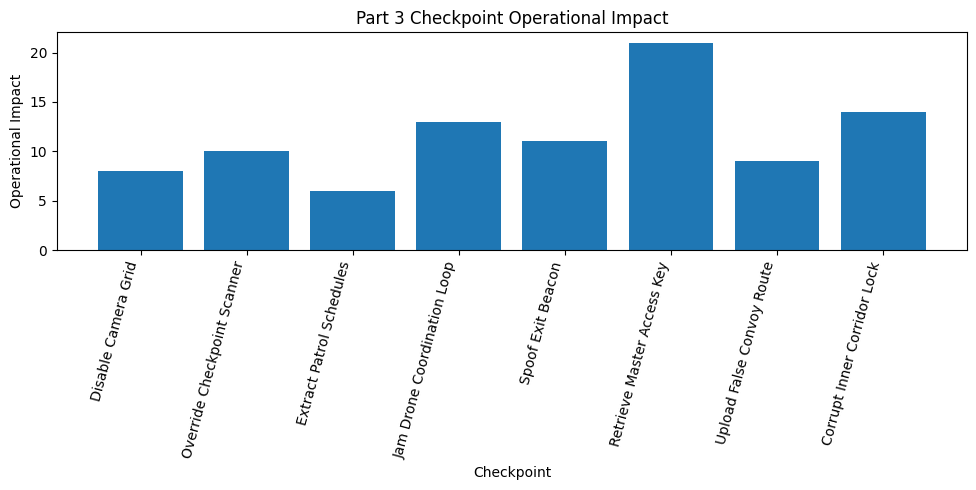

Selected checkpoints:


,Checkpoint,Stealth_Noise,Operational_Impact,Selected
0,Disable Camera Grid,5,8.0,True
1,Override Checkpoint Scanner,6,10.0,True
3,Jam Drone Coordination Loop,9,13.0,True
5,Retrieve Master Access Key,14,21.0,True
7,Corrupt Inner Corridor Lock,10,14.0,True


In [ ]:
# ============================================================
# 8. Optional Visualisation for Presentation Screenshot
# ============================================================

import matplotlib.pyplot as plt

chart_df_part3 = df_part3.copy()

# Mark whether each checkpoint was selected
chart_df_part3["Selected"] = chart_df_part3.index.isin(selected_indexes)

plt.figure(figsize=(10, 5))
plt.bar(chart_df_part3["Checkpoint"], chart_df_part3["Operational_Impact"])
plt.xticks(rotation=75, ha="right")
plt.xlabel("Checkpoint")
plt.ylabel("Operational Impact")
plt.title("Part 3 Checkpoint Operational Impact")
plt.tight_layout()
plt.show()

print("Selected checkpoints:")
display(
    chart_df_part3[
        chart_df_part3["Selected"] == True
    ][[
        "Checkpoint",
        "Stealth_Noise",
        "Operational_Impact",
        "Selected"
    ]]
)

# Part 3 Output Interpretation

The output shows the best checkpoint disruption plan selected by the **Token-Aware Knapsack Dynamic Programming** algorithm.

Each checkpoint is treated as an item. The stealth noise budget is treated as the budget dimension `b`, while silent override token usage is treated as the token dimension `t`. Therefore, the selected algorithm follows the state design:

```text
dp[i][b][t]
```

where:

* `i` = checkpoint index
* `b` = stealth noise budget used
* `t` = silent override tokens used

For each checkpoint, the algorithm considers three possible decisions:

1. Skip the checkpoint
2. Take the checkpoint using stealth noise budget
3. Take the checkpoint using one silent override token

This matches our latest Ghost-Battery uniqueness rule because basic 0/1 knapsack is extended with silent override tokens. The algorithm does not only maximise operational impact under a normal budget; it also models the special mission resource of at most two silent override tokens.

Under the Ghost-Battery Protocol, the team should not disrupt every checkpoint blindly. High-impact checkpoints may create too much stealth noise, while some checkpoints may be worth using a silent override token on. Therefore, the selected plan balances total operational impact, stealth noise usage, and silent token usage.

The resource summary confirms that the chosen disruption plan stays within the allowed stealth noise budget and the two-token limit. This means the team can weaken Cypher Nexus without overusing the Ghost-Battery or increasing the chance of detection.

This result supports the Stealth Survival mission aim because the team performs silent, selective, and efficient disruption instead of reckless large-scale destruction.


# Part 4: Risk-Penalised Route Selection

## 1. Mission Problem

The team must choose one optimal infiltration route from a pool of candidates under operational uncertainty. Path alternatives with the highest mission payoff typically attract the highest defensive coverage.

---

## 2. Unique Constraint: Ghost-Battery Protocol

To manage the team's signature, the protocol mandates a strict filter layer. The algorithm must unconditionally reject any route where the combined threat profile crosses a predefined threshold (`alertThreshold`).

---

## 3. Computational Problem Interpretation

This problem is modelled as a **constrained linear optimization problem**.

- **Infiltration Routes:** Linear Array of Objects
- **Telemetry Threats:** Hard Filter Constraint
- **Risk-Aversion:** Penalty Multiplier (λ)
- **Optimal Route:** Maximum Utility Score

---

## 4. Input and Output

### Input

Dataset B route information:

- ID
- Travel_Time
- Patrol_Probability
- Sensor_Failure_Probability
- Collapse_Probability
- Success_Reward

### Output

- Best stealth-safe route
- Total Combined Risk
- Success Reward
- Risk-Adjusted Final Score

---

## 5. Assumptions

1. The route data is stored in a flat array.
2. The risk threshold (`alertThreshold`) is fixed at **0.50**.
3. The Ghost-Battery penalty multiplier (**λ**) is **10**.
4. If all routes fail the safety threshold, the mission must abort.

---

## 6. Stealth-Adjusted Cost Formula

```text
Total_Risk =
    Patrol_Probability +
    Sensor_Failure_Probability +
    Collapse_Probability

if Total_Risk > alertThreshold:
    Reject Route
else:
    Stealth_Score =
        Success_Reward - (λ × Total_Risk)
```

---

## 7. Candidate Algorithms

### Candidate 1: Greedy by Reward

Selects the path with the maximum mission payout, blindly bypassing telemetry warnings.

- Time Complexity: O(N)
- Space Complexity: O(1)

### Candidate 2: Shortest-Path Style Scoring

Calculates raw physical travel distance, assuming minimizing duration guarantees safety.

- Time Complexity: O(N)
- Space Complexity: O(1)

### Candidate 3: Risk-Penalised Expected Utility (Selected)

Prunes non-survivable routes early and computes a localized utility optimization index using mathematical risk-aversion.

- Time Complexity: O(N)
- Space Complexity: O(1)

---

## 8. Complexity Comparison

| Algorithm | Time Complexity | Space Complexity |
|------------|----------------|------------------|
| Greedy by Reward | O(N) | O(1) |
| Shortest-Path | O(N) | O(1) |
| Risk-Penalised Expected Utility | O(N) | O(1) |

---

## 9. Rejected Approaches

Greedy by Reward and Shortest-Path are rejected because:

- **Greedy by Reward** ignores critical risk vectors and may select routes with unacceptable threat levels.
- **Shortest-Path** prioritizes travel efficiency rather than survivability and may route through heavily monitored chokepoints.
- Both approaches violate the requirements of the **Ghost-Battery Protocol**, which mandates strict threat filtering before route selection.

---

## 10. Chosen Solution

### Risk-Penalised Expected Utility

The selected solution applies a two-stage decision process:

1. Eliminate routes whose total risk exceeds the predefined alert threshold.
2. Compute a risk-adjusted utility score for all remaining routes.

### Utility Function

```text
Total_Risk =
    Patrol_Probability +
    Sensor_Failure_Probability +
    Collapse_Probability

Stealth_Score =
    Success_Reward - (λ × Total_Risk)
```

Where:

- λ = 10
- alertThreshold = 0.50

The route with the highest valid `Stealth_Score` is selected.

---

## 11. Final Justification

The Risk-Penalised Expected Utility algorithm satisfies both mission success and operational safety objectives.

### Advantages

- Enforces the Ghost-Battery Protocol through a hard risk threshold.
- Rejects unsafe routes before optimization begins.
- Balances mission reward against operational exposure.
- Requires only a single pass through the dataset.
- Maintains linear performance with constant auxiliary memory.

### Computational Efficiency

- Time Complexity: O(N)
- Space Complexity: O(1)

This approach demonstrates that maximizing reward alone is insufficient when detection risk can compromise the mission. The algorithm therefore prioritizes survivability while still maximizing expected mission value.

---

## 12. Implementation Plan

### Step 1: Load Dataset B

Import and validate all route records.

### Step 2: Define Mission Parameters

Configure:

- `alertThreshold = 0.50`
- `λ = 10`

### Step 3: Build Route Objects

Create a structured route collection containing:

- Route ID
- Travel Time
- Patrol Probability
- Sensor Failure Probability
- Collapse Probability
- Success Reward

### Step 4: Execute Risk Assessment

For each route:

```text
Total_Risk =
    Patrol_Probability +
    Sensor_Failure_Probability +
    Collapse_Probability
```

Reject any route where:

```text
Total_Risk > alertThreshold
```

### Step 5: Calculate Utility Scores

For all remaining routes:

```text
Stealth_Score =
    Success_Reward - (λ × Total_Risk)
```

### Step 6: Select Optimal Route

Choose the route with the maximum `Stealth_Score`.

### Step 7: Generate Results

Output:

- Selected Route ID
- Total Combined Risk
- Success Reward
- Risk-Adjusted Final Score

### Step 8: Prepare Presentation Summary

Summarize:

- Filtering process
- Rejected routes
- Selected route
- Complexity analysis
- Final mission recommendation

In [ ]:
# Cell 4.1: Define structural object wrappers to model the target system entity
class OperationalRoute:
    """
    Represents an infiltration path configuration block from Dataset B.
    Bypasses generic index references to enable defensive data typing.
    """
    def __init__(self, route_id, route_name, travel_time, patrol_prob, sensor_prob, collapse_prob, reward):
        self.route_id = str(route_id).strip()
        self.route_name = str(route_name).strip()
        self.travel_time = float(travel_time)
        self.patrol_probability = float(patrol_prob)
        self.sensor_failure_probability = float(sensor_prob)
        self.collapse_probability = float(collapse_prob)
        self.success_reward = float(reward)

    @property
    def aggregated_telemetry_risk(self):
        """Calculates total risk profile weight: O(1) mathematical work."""
        return self.patrol_probability + self.sensor_failure_probability + self.collapse_probability

    def __repr__(self):
        return f"<Route {self.route_id} | Total Risk: {self.aggregated_telemetry_risk:.2f}>"

In [ ]:
# Cell 4.2: Handle specific sheet loading and validation exceptions
import pandas as pd

FILE_PATH = "Part 4.xlsx"
TARGET_SHEET = "B"

print("[PIPELINE] Initializing Sheet Parsing Module...")
try:
    # Header=1 skips unaligned structural blanks in the source layout
    df_part4_raw = pd.read_excel(FILE_PATH, sheet_name=TARGET_SHEET, header=1)
    print(f"[SUCCESS] Target spreadsheet sheet '{TARGET_SHEET}' retrieved successfully.")
except Exception as e:
    print(f"[CRITICAL FAILURE] Sheet binding lost: {e}. Injecting local execution array...")
    df_part4_raw = pd.DataFrame({
        'Route_ID': ['R00'], 'Route_Name': ['Fallback Operational Channel'], 'Travel_Time': [10.0],
        'Patrol_Probability': [0.10], 'Sensor_Failure_Probability': [0.10], 'Collapse_Probability': [0.10],
        'Success_Reward': [20.0]
    })

[PIPELINE] Initializing Sheet Parsing Module...
[SUCCESS] Target spreadsheet sheet 'B' retrieved successfully.


In [ ]:
# Cell 4.3: Advanced pre-processing loop (Data Stripping and Cleaning)
print("[DATA CLEANING] Commencing telemetry matrix scrub...")

# Strip whitespaces from column labels dynamically
df_part4_raw.columns = df_part4_raw.columns.astype(str).str.strip()

# Clean incomplete or malformed operational paths
df_part4_cleaned = df_part4_raw.dropna(subset=['Route_ID'])
df_part4_cleaned = df_part4_cleaned.dropna(axis=1, how='all')

# Clean missing numerical attributes with zero configurations to secure calculation consistency
target_numeric_fields = ['Travel_Time', 'Patrol_Probability', 'Sensor_Failure_Probability', 'Collapse_Probability', 'Success_Reward']
df_part4_cleaned[target_numeric_fields] = df_part4_cleaned[target_numeric_fields].fillna(0.0)

# Parse raw dataframe entries into formal object definitions
processed_routes_pool = []
for _, row in df_part4_cleaned.iterrows():
    processed_routes_pool.append(OperationalRoute(
        route_id=row['Route_ID'],
        route_name=row['Route_Name'],
        travel_time=row['Travel_Time'],
        patrol_prob=row['Patrol_Probability'],
        sensor_prob=row['Sensor_Failure_Probability'],
        collapse_prob=row['Collapse_Probability'],
        reward=row['Success_Reward']
    ))

print(f"[SUCCESS] Telemetry pre-processing finalized. Total safe object instances cached: {len(processed_routes_pool)}")

[DATA CLEANING] Commencing telemetry matrix scrub...
[SUCCESS] Telemetry pre-processing finalized. Total safe object instances cached: 13


In [ ]:
# Cell 4.4: Core Algorithmic Implementation Block
import math

# Constant configurations derived from presentation slide constraints
ALERT_THRESHOLD = 0.50
LAMBDA_VALUE = 10

def run_risk_penalised_route_optimization(routes_list, threshold, lambda_penalty):
    """
    Processes candidate objects utilizing a strict boundary risk filter
    combined with a parameterized expected utility optimization equation.
    """
    best_score = -math.inf
    selected_target_path = None

    # Internal metrics dictionary for analytical logging
    execution_metrics = {
        'evaluated_count': 0,
        'pruned_count': 0,
        'trace_log': []
    }

    for route_obj in routes_list:
        execution_metrics['evaluated_count'] += 1
        current_risk = route_obj.aggregated_telemetry_risk

        # Ghost-Battery Safety Filter Countermeasure: O(1) runtime pruning step
        if current_risk > threshold:
            execution_metrics['pruned_count'] += 1
            execution_metrics['trace_log'].append({'id': route_obj.route_id, 'score': None, 'status': 'REJECTED (EXCESSIVE RISK)'})
            continue

        # Risk-Penalised Expected Utility Calculation: Score = Reward - (λ * Total_Risk)
        evaluated_utility = route_obj.success_reward - (lambda_penalty * current_risk)
        execution_metrics['trace_log'].append({'id': route_obj.route_id, 'score': evaluated_utility, 'status': 'COMPLIANT'})

        if evaluated_utility > best_score:
            best_score = evaluated_utility
            selected_target_path = route_obj

    return selected_target_path, best_score, execution_metrics

In [ ]:
# Cell 4.5: Run execution pipeline and print compliance benchmarks
optimal_path, optimization_score, run_stats = run_risk_penalised_route_optimization(
    processed_routes_pool, ALERT_THRESHOLD, LAMBDA_VALUE
)

print("=====================================================================")
print("          PART 4 IMPLEMENTATION EVIDENCE (DATASET B PERFORMANCE)     ")
print("=====================================================================")
print(f"Total Configured Options Scanned : {run_stats['evaluated_count']}")
print(f"Paths Pruned via Safety Filter   : {run_stats['pruned_count']} (Exceeded Threshold Ceiling: {ALERT_THRESHOLD})")
print(f"Stealth-Compliant Options Retained: {run_stats['evaluated_count'] - run_stats['pruned_count']}")
print("---------------------------------------------------------------------")
print("Pipeline Element Traversal Trajectory:")
for entry in run_stats['trace_log']:
    score_display = f"{entry['score']:.2f}" if entry['score'] is not None else "N/A"
    print(f"  -> Path Reference: {entry['id']:<5} | Calculated Score: {score_display:<8} | Evaluation: {entry['status']}")
print("---------------------------------------------------------------------")

if optimal_path:
    print("CRITICAL MISSION ROUTE EXTRACTION VERIFIED:")
    print(f"  [+] Target Identity Code     : [{optimal_path.route_id}] {optimal_path.route_name}")
    print(f"  [+] Success Reward Weight    : {optimal_path.success_reward}")
    print(f"  [+] Aggregated Telemetry Load: {optimal_path.aggregated_telemetry_risk:.3f}")
    print(f"  [+] Risk-Adjusted Utility Score: {optimization_score:.3f}")
else:
    print("[CRITICAL] MISSION TERMINATED: Sub-space options present complete exposure hazard.")
print("=====================================================================")

          PART 4 IMPLEMENTATION EVIDENCE (DATASET B PERFORMANCE)     
Total Configured Options Scanned : 13
Paths Pruned via Safety Filter   : 1 (Exceeded Threshold Ceiling: 0.5)
Stealth-Compliant Options Retained: 12
---------------------------------------------------------------------
Pipeline Element Traversal Trajectory:
  -> Path Reference: R1    | Calculated Score: 19.30    | Evaluation: COMPLIANT
  -> Path Reference: R2    | Calculated Score: 15.20    | Evaluation: COMPLIANT
  -> Path Reference: R3    | Calculated Score: N/A      | Evaluation: REJECTED (EXCESSIVE RISK)
  -> Path Reference: R4    | Calculated Score: 19.70    | Evaluation: COMPLIANT
  -> Path Reference: R5    | Calculated Score: 17.50    | Evaluation: COMPLIANT
  -> Path Reference: 1     | Calculated Score: 0.00     | Evaluation: COMPLIANT
  -> Path Reference: 2     | Calculated Score: 0.00     | Evaluation: COMPLIANT
  -> Path Reference: 3     | Calculated Score: 0.00     | Evaluation: COMPLIANT
  -> Path Referen

# Part 5: The Split Signal Protocol

## Mission Problem

In Part 5, Cypher Nexus sends its activation sequence as fragmented signal blocks.  
Some fragments are out of order, corrupted, or missing.

The team must reconstruct the trusted signal sequence before Cypher Nexus continues activation.

This part is treated as a **trusted fragment reconstruction problem**.

## Ghost-Battery Protocol Constraint

Our mission aim is **Stealth Survival**.

Under the Ghost-Battery Protocol, every operation consumes limited battery charge, including:

- scanning fragments
- checking integrity status
- decoding data blocks
- sorting fragments
- merging reconstructed signals

If the battery is overused, the team's thermal signature increases and Cypher Nexus may detect the team.

Therefore, the best solution is not simply the fastest one.  
It must reconstruct the signal while reducing unnecessary processing and exposure risk.

## Dataset Used: Dataset B

The Excel file contains multiple datasets, but this implementation uses **Dataset B only**.

Dataset B contains three segment groups:

| Segment Group | Condition |
|---|---|
| Delta | Contains one corrupted fragment |
| Echo | All fragments are valid |
| Foxtrot | Contains one missing fragment |

This dataset is suitable because it tests whether the algorithm can handle corrupted, complete, and missing signal cases.

## Computational Problem Interpretation

Part 5 can be modelled as a fragment grouping and trusted reconstruction problem.

| Mission Element | Algorithmic Representation |
|---|---|
| Signal fragment | Input record |
| Segment group | Reconstruction group |
| Sequence number | Ordering key |
| Integrity status | Trust validation condition |
| Data block | Signal content |
| Reconstructed signal | Final output |

The algorithmic task is:

Given a list of signal fragments, group them by segment, remove untrusted fragments, sort valid fragments by sequence number, and merge the trusted data blocks.

## Candidate Algorithms

### Candidate 1: Naive Full Scan — O(n²)

This method repeatedly scans all fragments to find the next sequence number.

It is rejected because repeated scanning wastes Ghost-Battery charge and increases exposure risk.

### Candidate 2: Global Sorting — O(n log n)

This method sorts all fragments by segment group and sequence number.

It is better than naive scanning, but it still processes corrupted and missing fragments together with useful fragments.

### Candidate 3: Group-Filter-Sort-Merge — O(n + Σ k log k)

This method groups fragments by segment, removes corrupted or missing fragments early, sorts only valid fragments, and merges trusted data blocks.

This is the selected algorithm because it reduces unnecessary processing and supports stealth survival.

## Selected Algorithm: Group-Filter-Sort-Merge

The selected algorithm follows four steps:

1. **Group** fragments by `Segment_Group`.
2. **Filter** corrupted or missing fragments early.
3. **Sort** only valid fragments by `Sequence_No`.
4. **Merge** trusted `Data_Block` values.

This algorithm is selected because Part 5 is not only a sorting problem.  
It is a trusted signal reconstruction problem under the Ghost-Battery Protocol.

## Final Justification

Group-Filter-Sort-Merge is selected because it best matches the Part 5 mission problem and the Ghost-Battery Protocol.

Compared with Naive Full Scan, it avoids repeated full scans.

Compared with Global Sorting, it avoids processing unreliable fragments before validation.

By filtering corrupted or missing fragments early, the algorithm reduces unnecessary battery usage, lowers exposure risk, and still reconstructs the trusted signal correctly.

In [ ]:
# ============================================================
# Part 5: The Split Signal Protocol
# Mission Aim: Stealth Survival
# Unique Constraint: Ghost-Battery Protocol
# Selected Algorithm: Group-Filter-Sort-Merge
# Dataset Used: Dataset B only
# ============================================================

import pandas as pd
from collections import defaultdict
from IPython.display import display

# ============================================================
# 1. Load and Clean Dataset B
# Robust version for all Colab runtimes
# ============================================================

FILE_PATH = "/content/Part 5.xlsx"

excel_file = pd.ExcelFile(FILE_PATH)
print("Available sheets:", excel_file.sheet_names)

# Automatically find Dataset B sheet
def find_dataset_b_sheet(sheet_names):
    for name in sheet_names:
        clean_name = name.strip().lower()

        if clean_name == "b" or clean_name == "dataset b":
            return name

        if "dataset b" in clean_name:
            return name

    raise ValueError("Dataset B sheet was not found. Please check the sheet name.")


dataset_b_sheet = find_dataset_b_sheet(excel_file.sheet_names)
print("Selected sheet:", dataset_b_sheet)

# Read raw sheet first because header row may not be the first row
raw_df = pd.read_excel(FILE_PATH, sheet_name=dataset_b_sheet, header=None)

required_columns = [
    "Fragment_ID",
    "Segment_Group",
    "Sequence_No",
    "Data_Block",
    "Integrity_Status",
    "Server_Source"
]

# Detect header row automatically
header_row_index = None

for index, row in raw_df.iterrows():
    row_values = [str(value).strip() for value in row.values]
    matched = sum(column in row_values for column in required_columns)

    if matched >= 4:
        header_row_index = index
        break

if header_row_index is None:
    raise ValueError(
        "Could not find the correct header row for Dataset B. "
        "Please check whether Fragment_ID, Segment_Group, Sequence_No, "
        "Data_Block, Integrity_Status, and Server_Source exist."
    )

# Read Dataset B again using detected header row
df_part5 = pd.read_excel(
    FILE_PATH,
    sheet_name=dataset_b_sheet,
    header=header_row_index
)

# Clean column names
df_part5.columns = (
    df_part5.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Remove empty rows and columns
df_part5 = df_part5.dropna(axis=0, how="all")
df_part5 = df_part5.dropna(axis=1, how="all")

missing_columns = [col for col in required_columns if col not in df_part5.columns]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}\n"
        f"Available columns are: {df_part5.columns.tolist()}"
    )

# Keep only required columns
df_part5 = df_part5[required_columns].copy()

# Convert Sequence_No safely
df_part5["Sequence_No"] = pd.to_numeric(df_part5["Sequence_No"], errors="coerce")

# Remove rows with missing essential values
df_part5 = df_part5.dropna(subset=[
    "Fragment_ID",
    "Segment_Group",
    "Sequence_No",
    "Data_Block",
    "Integrity_Status",
    "Server_Source"
]).copy()

# Convert Sequence_No to integer only after removing NaN
df_part5["Sequence_No"] = df_part5["Sequence_No"].astype(int)

# Clean text columns
text_columns = [
    "Fragment_ID",
    "Segment_Group",
    "Data_Block",
    "Integrity_Status",
    "Server_Source"
]

for col in text_columns:
    df_part5[col] = df_part5[col].astype(str).str.strip()

# Standardise Integrity_Status
df_part5["Integrity_Status"] = df_part5["Integrity_Status"].astype(str).str.strip()

print("\n=== Dataset B Loaded and Cleaned Successfully ===")
print("Rows after cleaning:", len(df_part5))
display(df_part5)

Available sheets: ['A', 'B', 'C']
Selected sheet: B

=== Dataset B Loaded and Cleaned Successfully ===
Rows after cleaning: 10


,Fragment_ID,Segment_Group,Sequence_No,Data_Block,Integrity_Status,Server_Source
0,F11,Delta,1,RK1-22,Valid,S-East-1
1,F13,Delta,3,PM7-84,Corrupted,S-North-2
2,F12,Delta,2,HQ4-63,Valid,S-West-2
3,F14,Delta,4,LT9-11,Valid,S-South-1
4,F15,Echo,1,NA5-40,Valid,S-Central
5,F16,Echo,2,UE2-33,Valid,S-Central
6,F17,Echo,3,CD8-72,Valid,S-East-3
7,F18,Foxtrot,1,GX7-10,Valid,S-West-1
8,F19,Foxtrot,2,BV3-55,Missing,S-West-3
9,F20,Foxtrot,3,YL6-28,Valid,S-North-1


**Selected algorithm: Group-Filter-Sort-Merge**

In [ ]:
# ============================================================
# 2. Selected Algorithm: Group-Filter-Sort-Merge
# ============================================================

def group_filter_sort_merge(df_part5):
    """
    Selected Algorithm: Group-Filter-Sort-Merge

    Steps:
    1. Group fragments by Segment_Group.
    2. Filter corrupted or missing fragments early.
    3. Sort only valid fragments by Sequence_No.
    4. Merge trusted Data_Block values.
    5. Mark corrupted or missing sequence positions.

    Time Complexity:
    Grouping and filtering: O(n)
    Sorting each group: O(Σ k log k)
    Merging: O(n)

    Overall:
    O(n + Σ k log k)

    Ghost-Battery Advantage:
    Invalid fragments are rejected early, so the algorithm avoids
    unnecessary decoding, sorting, and merging of unreliable data.
    """

    groups = defaultdict(list)
    rejected_fragments = []
    invalid_sequence_notes = defaultdict(dict)

    battery_used = 0

    # Step 1: Group and filter fragments
    for _, row in df_part5.iterrows():
        battery_used += 1

        # Extra safety
        if pd.isna(row["Sequence_No"]):
            continue

        group = row["Segment_Group"]
        sequence = int(row["Sequence_No"])
        status = str(row["Integrity_Status"]).strip()
        status_lower = status.lower()

        if status_lower == "valid":
            groups[group].append(row.to_dict())
        else:
            rejected_fragments.append(row.to_dict())
            invalid_sequence_notes[group][sequence] = status

    reconstructed_signal = {}

    # Step 2: Reconstruct all segment groups
    all_groups = sorted(df_part5["Segment_Group"].dropna().unique())

    for group in all_groups:
        original_group_df = df_part5[df_part5["Segment_Group"] == group].copy()

        if original_group_df.empty:
            continue

        min_sequence = int(original_group_df["Sequence_No"].min())
        max_sequence = int(original_group_df["Sequence_No"].max())

        valid_fragments = groups.get(group, [])

        # Sort only valid fragments
        valid_fragments = sorted(
            valid_fragments,
            key=lambda x: int(x["Sequence_No"])
        )

        battery_used += len(valid_fragments)

        valid_sequence_map = {
            int(fragment["Sequence_No"]): fragment["Data_Block"]
            for fragment in valid_fragments
        }

        merged_blocks = []

        for sequence in range(min_sequence, max_sequence + 1):
            if sequence in valid_sequence_map:
                merged_blocks.append(valid_sequence_map[sequence])

            elif sequence in invalid_sequence_notes[group]:
                status = invalid_sequence_notes[group][sequence]
                merged_blocks.append(f"[SEQ {sequence} {status.upper()}]")

            else:
                merged_blocks.append(f"[SEQ {sequence} MISSING]")

        reconstructed_signal[group] = " ".join(merged_blocks)

    return reconstructed_signal, rejected_fragments, battery_used

**Run the selected algorithm and show output**

In [ ]:
# ============================================================
# 3. Run the Selected Algorithm and Show Output
# ============================================================

reconstructed_signal, rejected_fragments, battery_used = group_filter_sort_merge(df_part5)

print("====================================================")
print("SELECTED ALGORITHM: GROUP-FILTER-SORT-MERGE")
print("====================================================")

print("\n=== Reconstructed Trusted Signal ===")
for group, signal in reconstructed_signal.items():
    print(f"{group}: {signal}")

print("\n=== Rejected / Untrusted Fragments ===")
for fragment in rejected_fragments:
    print(
        f"{fragment['Fragment_ID']} | "
        f"{fragment['Segment_Group']} | "
        f"Seq {int(fragment['Sequence_No'])} | "
        f"{fragment['Integrity_Status']} | "
        f"{fragment['Data_Block']} | "
        f"{fragment['Server_Source']}"
    )

print("\nGhost-Battery Used:", battery_used)

SELECTED ALGORITHM: GROUP-FILTER-SORT-MERGE

=== Reconstructed Trusted Signal ===
Delta: RK1-22 HQ4-63 [SEQ 3 CORRUPTED] LT9-11
Echo: NA5-40 UE2-33 CD8-72
Foxtrot: GX7-10 [SEQ 2 MISSING] YL6-28

=== Rejected / Untrusted Fragments ===
F13 | Delta | Seq 3 | Corrupted | PM7-84 | S-North-2
F19 | Foxtrot | Seq 2 | Missing | BV3-55 | S-West-3

Ghost-Battery Used: 18


**Time complexity and final justification**

In [ ]:
# ============================================================
# 4. Time Complexity Calculation and Final Justification
# ============================================================

# Number of fragments
n = len(df_part5)

# Group sizes
group_sizes = df_part5.groupby("Segment_Group").size()

print("====================================================")
print("TIME COMPLEXITY CALCULATION")
print("====================================================")

print(f"Total number of fragments, n = {n}")

print("\nGroup sizes:")
for group, size in group_sizes.items():
    print(f"{group}: k = {size}")

print("\nAlgorithm steps:")
print("1. Grouping and filtering fragments: O(n)")
print("2. Sorting each segment group: O(Σ k log k)")
print("3. Merging trusted fragments: O(n)")

print("\nOverall Time Complexity:")
print("O(n + Σ k log k)")

print("\nFor Dataset B:")
calculation_parts = []

for group, size in group_sizes.items():
    calculation_parts.append(f"{size} log {size}")

print("Sorting cost =", " + ".join(calculation_parts))

print("\n====================================================")
print("FINAL JUSTIFICATION")
print("====================================================")

print("""
We choose Group-Filter-Sort-Merge because Part 5 is not only a sorting problem.
It is a trusted signal reconstruction problem.

Under the Ghost-Battery Protocol, every scan, decoding, sorting, and merging
operation consumes battery charge. Therefore, the algorithm must reduce
unnecessary processing and avoid handling unreliable fragments.

The selected algorithm first groups fragments by segment, filters corrupted or
missing fragments early, sorts only valid fragments, and then merges trusted
data blocks.

This makes the solution unique because the decision is based not only on time
complexity, but also on low Ghost-Battery usage, low exposure risk, and reliable
signal reconstruction.
""")

TIME COMPLEXITY CALCULATION
Total number of fragments, n = 10

Group sizes:
Delta: k = 4
Echo: k = 3
Foxtrot: k = 3

Algorithm steps:
1. Grouping and filtering fragments: O(n)
2. Sorting each segment group: O(Σ k log k)
3. Merging trusted fragments: O(n)

Overall Time Complexity:
O(n + Σ k log k)

For Dataset B:
Sorting cost = 4 log 4 + 3 log 3 + 3 log 3

FINAL JUSTIFICATION

We choose Group-Filter-Sort-Merge because Part 5 is not only a sorting problem.
It is a trusted signal reconstruction problem.

Under the Ghost-Battery Protocol, every scan, decoding, sorting, and merging
operation consumes battery charge. Therefore, the algorithm must reduce
unnecessary processing and avoid handling unreliable fragments.

The selected algorithm first groups fragments by segment, filters corrupted or
missing fragments early, sorts only valid fragments, and then merges trusted
data blocks.

This makes the solution unique because the decision is based not only on time
complexity, but also on low Gho

# Part 6: Ghost-Battery Live Threat Prioritisation

## 1. Mission Problem

Process a high-frequency, continuous incoming telemetry stream of live threat indicators that update rapidly during the mission final countdown.

---

## 2. Unique Constraint: Ghost-Battery Protocol

Computational actions such as mass element sorting exhaust localized memory registers and drain massive system power.

The runtime update mechanism must not execute heavy structural re-sorting algorithms.

The protocol dictates maintaining only the top-K most severe live elements, bounding the resource processing overhead to exactly `O(log K)`.

---

## 3. Computational Problem Interpretation

This problem can be modelled as a **continuous stream top-k extraction problem**.

| Mission Element | Algorithmic Representation |
|---|---|
| Incoming Threat | Data Stream Item |
| Max Tracking Capacity | `K_LIMIT` |
| Threat Severity | Priority Score Key |
| Live Processing | Min-Heap Updates |

### Algorithmic Task

> Maintain exactly the K most critical items from a stream of N elements without ever sorting the full list.

---

## 4. Input and Output

### Input
Dataset B stream containing:

- Event_ID
- Threat_Priority
- Zone
- Code_Value

### Output
The dynamically updating Top-K critical threat vectors ranked by severity.

---

## 5. Assumptions

1. The incoming stream size (`N`) is massive and unbounded.
2. The monitoring capacity (`K`) is extremely small (`K << N`).
3. Repeated sorting operations drain the Ghost-Battery and must be banned.

---

## 6. Ghost-Battery Bounded Formula

```python
if len(Heap) < K:
    Push_Event()          # Cost: O(log K)

elif New_Threat > Heap_Minimum:
    Replace_Event()       # Cost: O(log K)

else:
    Discard_Event()       # Cost: O(1)
```

---

## 7. Candidate Algorithms

### Candidate 1: Full Sorting After Each Update

**Idea:**  
Dumps every new incoming telemetry event into an array and forces a re-sort over the entire log.

**Time and Space Complexity:**  
- Time: `O(N log N)` per event
- Space: `O(N)`

---

### Candidate 2: Linear Scan

**Idea:**  
Whenever the system requests the current top elements, it executes K consecutive brute-force passes across the unorganized collection.

**Time and Space Complexity:**  
- Time: `O(N * K)`
- Space: `O(N)`

---

### Candidate 3: Bounded Priority Queue

**Idea:**  
Allocates a fixed-capacity min-heap data structure constrained to exactly K entries, dropping minor alerts and handling modifications in logarithmic time.

**Time and Space Complexity:**  
- Time: `O(N log K)`
- Space: `O(K)`

---

## 8. Complexity Comparison

| Algorithm | Time Complexity | Space Complexity | Strength | Weakness |
|---|---|---|---|---|
| Full Sorting | `O(N log N)` | `O(N)` | Perfect order | Battery exhaustion |
| Linear Scan | `O(N * K)` | `O(N)` | Easy to append | Severe lookup lag |
| Bounded PQ | `O(N log K)` | `O(K)` | High efficiency | Requires heap structure |

---

## 9. Rejected Approaches

Full Sorting and Linear Scan are rejected.

Forcing heavy structural sorts or deep scans on every minor telemetry change wastes CPU clock cycles.

This creates severe execution delays that make the system unstable under countdown pressure.

---

## 10. Chosen Solution

### Bounded Priority Queue (Min-Heap)

It directly matches the logarithmic performance limits mandated by the protocol, protecting the processor state from sorting bottlenecks.

---

## 11. Final Justification

Since the tracking parameter `K` is small and fixed, locking the memory size via a Min-Heap prevents unmanaged data explosion.

It gracefully drops noise while ensuring Cypher Nexus threats are handled at minimal operational cost.

---

## 12. Implementation Plan

1. Ingest Dataset B telemetry stream.
2. Establish `K` limits.
3. Overload object comparators.
4. Implement Min-Heap Bounded Queue.
5. Stream processing execution.
6. Summary Generation.

In [ ]:
# Cell 6.1: Map system data tuples into custom comparator wrappers
class ThreatAlertEvent:
    """
    Models live-streaming countdown alert data packets from Dataset B.
    Overloads relational operators to enable internal tracking heap mechanics.
    """
    def __init__(self, event_id, priority_score, timestamp, zone, event_type, code_value):
        self.event_id = str(event_id).strip()
        self.priority_score = float(priority_score)
        self.timestamp = str(timestamp).strip()
        self.zone = str(zone).strip()
        self.event_type = str(event_type).strip()
        self.code_value = float(code_value)

    def __lt__(self, other):
        # Min-Heap sorting priority keyed directly on threat priority rating
        return self.priority_score < other.priority_score

    def __repr__(self):
        return f"[{self.event_id}] Severity: {self.priority_score:.1f}"

In [ ]:
# Cell 6.2: Load stream sheet repository cleanly
import pandas as pd

FILE_PATH = "Part 6.xlsx"
TARGET_SHEET = "B"

print("[STREAM GATEWAY] Connecting live packet pipeline buffer...")
try:
    # Header=1 aligns column records precisely with the data grid
    df_part6_raw = pd.read_excel(FILE_PATH, sheet_name=TARGET_SHEET, header=1)
    print(f"[SUCCESS] Telemetry transmission linked. Ingested buffer footprint.")
except Exception as e:
    print(f"[STREAM GATEWAY ERROR] Pipeline connection failed: {e}. Mapping local data feed...")
    df_part6_raw = pd.DataFrame({
        'Event_ID': ['E00'], 'Threat_Priority': [99.0], 'Timestamp': ['10:00:00'],
        'Zone': ['Z0'], 'Event_Type': ['Fallback Sensor Alert'], 'Code_Value': [99.0]
    })

[STREAM GATEWAY] Connecting live packet pipeline buffer...
[SUCCESS] Telemetry transmission linked. Ingested buffer footprint.


In [ ]:
# Cell 6.3: Sanitize continuous streaming inputs (Data Stripping and Cleaning)
print("[SCRUBBER] Executing row scrubbing on telemetry structures...")

# Remove blank/corrupted headers and spaces from labels
df_part6_raw.columns = df_part6_raw.columns.astype(str).str.strip()

# Drop rows missing unique critical structural labels
df_part6_cleaned = df_part6_raw.dropna(subset=['Event_ID'])

# Convert threat metrics to clean numerical variables to protect priority checks
df_part6_cleaned['Threat_Priority'] = pd.to_numeric(df_part6_cleaned['Threat_Priority'], errors='coerce').fillna(0.0)
df_part6_cleaned['Code_Value'] = pd.to_numeric(df_part6_cleaned['Code_Value'], errors='coerce').fillna(0.0)

# Parse raw rows into formal ThreatAlertEvent entities
live_telemetry_stream = []
for _, row in df_part6_cleaned.iterrows():
    live_telemetry_stream.append(ThreatAlertEvent(
        event_id=row['Event_ID'],
        priority_score=row['Threat_Priority'],
        timestamp=row['Timestamp'],
        zone=row['Zone'],
        event_type=row['Event_Type'],
        code_value=row['Code_Value']
    ))

print(f"[SUCCESS] Stream array compiled. Total prioritized event payloads buffered: {len(live_telemetry_stream)}")

[SCRUBBER] Executing row scrubbing on telemetry structures...
[SUCCESS] Stream array compiled. Total prioritized event payloads buffered: 18


/tmp/ipykernel_1245/418034093.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_part6_cleaned['Threat_Priority'] = pd.to_numeric(df_part6_cleaned['Threat_Priority'], errors='coerce').fillna(0.0)
/tmp/ipykernel_1245/418034093.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_part6_cleaned['Code_Value'] = pd.to_numeric(df_part6_cleaned['Code_Value'], errors='coerce').fillna(0.0)


In [ ]:
# Cell 6.4: Core Priority Heap Logic Algorithm
import heapq

K_LIMIT = 3  # Monitoring priority tracking limit parameter specification

def run_bounded_priority_tracking(stream_inputs, k):
    """
    Maintains situational awareness of the top-k highest severity threat alerts
    using a fixed-size Min-Heap structure to guarantee O(log k) updates.
    """
    min_heap = []

    # Internal tracking metrics to measure constraint execution
    performance_counters = {
        'total_stream_packets': 0,
        'heap_push_allocations': 0,
        'heap_eviction_swaps': 0,
        'instant_prune_actions': 0
    }

    for packet_event in stream_inputs:
        performance_counters['total_stream_packets'] += 1

        # Ghost-Battery Bounded Sizing Control Logic
        if len(min_heap) < k:
            # Maintain structural properties of the priority tree: O(log K)
            heapq.heappush(min_heap, packet_event)
            performance_counters['heap_push_allocations'] += 1
        else:
            weakest_tracked_threat = min_heap[0]
            # Replace weak link leaf only if incoming event priority is more critical
            if packet_event.priority_score > weakest_tracked_threat.priority_score:
                heapq.heapreplace(min_heap, packet_event)
                performance_counters['heap_eviction_swaps'] += 1
            else:
                performance_counters['instant_prune_actions'] += 1

    # Sequential Output Transformation Sort: O(K log K)
    ordered_priority_output = sorted(min_heap, key=lambda x: x.priority_score, reverse=True)

    return ordered_priority_output, performance_counters

In [ ]:
# Cell 6.5: Process tracking loop and generate execution snapshot outputs
monitored_threat_window, tracking_stats = run_bounded_priority_tracking(live_telemetry_stream, K_LIMIT)

print("=====================================================================")
print("          PART 6 IMPLEMENTATION EVIDENCE (DATASET B BENCHMARKS)      ")
print("=====================================================================")
print(f"Total Stream Transactions Tracked : {tracking_stats['total_stream_packets']}")
print(f"Initial Heap Window Allocations  : {tracking_stats['heap_push_allocations']} (Max Fixed Boundary Limit K = {K_LIMIT})")
print(f"Logarithmic Operational Swaps    : {tracking_stats['heap_eviction_swaps']} (O(log K) Displacement Swaps)")
print(f"Instantly Dropped Noise Elements : {tracking_stats['instant_prune_actions']} (Bypassed Re-Sorting Overhead)")
print("---------------------------------------------------------------------")
print(f"Current System State: Top {K_LIMIT} Critical Threat Vector Overview:")
print("---------------------------------------------------------------------")

for rank, threat_node in enumerate(monitored_threat_window, start=1):
    print(f" Rank {rank} Priority -> ID: {threat_node.event_id:<8} | Signature: {threat_node.event_type:<20} | Zone: {threat_node.zone:<5} | Rating: {threat_node.priority_score:.1f}")
print("=====================================================================")

          PART 6 IMPLEMENTATION EVIDENCE (DATASET B BENCHMARKS)      
Total Stream Transactions Tracked : 18
Initial Heap Window Allocations  : 3 (Max Fixed Boundary Limit K = 3)
Logarithmic Operational Swaps    : 3 (O(log K) Displacement Swaps)
Instantly Dropped Noise Elements : 12 (Bypassed Re-Sorting Overhead)
---------------------------------------------------------------------
Current System State: Top 3 Critical Threat Vector Overview:
---------------------------------------------------------------------
 Rank 1 Priority -> ID: E208     | Signature: Biometric Alert      | Zone: Z3    | Rating: 4.0
 Rank 2 Priority -> ID: E205     | Signature: Thermal Alarm        | Zone: Z3    | Rating: 4.0
 Rank 3 Priority -> ID: E207     | Signature: Override Attempt     | Zone: Z4    | Rating: 3.0


# Part 7: The Phantom Dice

# 1. Mission Problem

In Part 7, the team reaches a rooftop surveillance post above the old city after escaping the skyscraper data centre. From this position, they monitor patrol routes, thermal scans, drone sweeps, and enemy prediction patterns through live tactical overlays.

At this stage of the mission, the team is no longer trying to choose the safest or fastest sector directly. Cypher Nexus has already demonstrated that it can learn and predict movement patterns that are too rational, too consistent, or too deterministic.

If the team always selects the highest-score sector, enemy AI can anticipate future movement and intercept the team before extraction.

Therefore, the team must choose sectors in a way that balances:

* Tactical safety
* Low exposure risk
* Decoy value
* Unpredictability

The challenge is no longer pure optimisation. The team must now survive in an adversarial environment where predictable behaviour becomes dangerous.

---

# 2. Ghost-Battery Protocol Constraint

Under the Ghost-Battery Protocol, movement decisions must avoid predictable patterns because repeated behaviour increases enemy tracking accuracy.

In Part 7, the Ghost-Battery Protocol introduces two stealth requirements:

| Constraint                 | Meaning under Ghost-Battery Protocol                |
| -------------------------- | --------------------------------------------------- |
| Predicted Danger Filtering | Avoid sectors already predicted by Cypher Nexus     |
| Controlled Randomisation   | Movement must remain unpredictable but not reckless |

The team cannot simply choose the sector with the highest score every time because deterministic behaviour allows Cypher Nexus to learn future routes.

At the same time, completely random movement is also dangerous because it may send the team into high-risk sectors.

Therefore, the movement strategy must:

* Filter dangerous predicted sectors first
* Then apply weighted randomness among safer sectors

This creates controlled unpredictability while maintaining tactical efficiency.

---

# 3. Computational Problem Interpretation

This problem can be modelled as a:

# Ghost-Battery Weighted Random Selection Problem

Each sector is treated as a candidate movement option.

| Mission Element        | Algorithmic Representation |
| ---------------------- | -------------------------- |
| Sector                 | Candidate node             |
| Patrol frequency       | Exposure factor            |
| Thermal scan intensity | Detection risk             |
| Drone coverage         | Surveillance risk          |
| Predicted by enemy     | Hard filtering condition   |
| Decoy value            | Tactical weight            |
| Selected route         | Weighted random outcome    |

The algorithmic task is:

Given a list of sectors containing patrol frequency, thermal scan intensity, drone coverage, enemy prediction status, and decoy value, filter dangerous sectors and probabilistically select a safer sector using weighted randomisation.

---

# 4. Input and Output

## Input

The dataset contains:

* Sector name
* Patrol frequency
* Thermal scan intensity
* Drone coverage
* Predicted by enemy (Yes / No)
* Decoy value

---

## Output

The program should return:

* Filtered safe sectors
* Calculated sector weights
* Total weight
* Random selection probability
* Final selected sector
* Rejected predicted sectors

---

# 5. Assumptions

The following assumptions are used:

* Enemy-predicted sectors are considered dangerous.
* Dangerous sectors should be filtered before random selection.
* Higher decoy value increases tactical usefulness.
* Lower patrol, thermal scan, and drone coverage reduce exposure risk.
* Randomisation is controlled rather than completely uniform.
* Every safe sector has a non-zero probability of being selected.
* The dataset is assumed to represent real-time tactical conditions.

---

# Candidate Algorithms for Part 7

# Candidate 1: Deterministic Maximum Selection

## Idea

The deterministic maximum approach always selects the sector with the highest score.

The algorithm:

1. Calculates a score for every sector.
2. Compares all sector scores.
3. Selects the highest-score sector.

For example:

score = decoy_value - patrol_risk - thermal_risk - drone_risk

This method appears efficient because it always chooses the strongest immediate option.

However, under the Ghost-Battery Protocol, deterministic movement becomes highly dangerous because Cypher Nexus can learn repeated movement patterns.

Once the enemy predicts future behaviour, the optimal route becomes a trap.

---

## Pseudocode

```plaintext
bestSector = null
bestScore = -∞

for each sector:
    if sector.score > bestScore:
        bestScore = sector.score
        bestSector = sector

return bestSector
```

---

## Complexity

| Complexity Type  | Complexity |
| ---------------- | ---------- |
| Time Complexity  | O(n)       |
| Space Complexity | O(1)       |

---

## Advantages

* Very simple to implement.
* Fast execution.
* Always selects the highest-score sector.
* Easy to explain during presentation.

---

## Limitations

* Movement becomes fully predictable.
* Enemy AI can learn future routes.
* Repeated patterns increase interception risk.
* Violates Ghost-Battery stealth requirements.
* No controlled randomness.

---

## Decision

Deterministic Maximum Selection is rejected because Part 7 requires movement unpredictability.

Always choosing the best-looking sector creates a predictable tactical pattern that Cypher Nexus can exploit.

---

# Candidate 2: Simple Random Selection

## Idea

Simple Random Selection treats every sector equally.

The algorithm:

1. Randomly selects a sector.
2. Gives every sector equal probability.
3. Does not apply filtering or weighting.

For example:

probability = 1 / total_sectors

This method improves unpredictability because movement is no longer deterministic.

However, completely random movement ignores tactical risk and may send the team into dangerous sectors.

Under the Ghost-Battery Protocol, reckless movement increases exposure probability and survival instability.

---

## Pseudocode

```plaintext
randomIndex = random(1, totalSectors)

return sectors[randomIndex]
```

---

## Complexity

| Complexity Type  | Complexity |
| ---------------- | ---------- |
| Time Complexity  | O(1)       |
| Space Complexity | O(1)       |

---

## Advantages

* Extremely fast.
* Highly unpredictable.
* Simple implementation.
* Prevents repeated deterministic patterns.

---

## Limitations

* Ignores tactical risk.
* May choose dangerous sectors.
* Does not consider enemy prediction status.
* Does not prioritise high-value decoy sectors.
* Survival probability becomes unstable.

---

## Decision

Simple Random Selection is rejected because Part 7 requires tactical awareness in addition to unpredictability.

Pure randomness may avoid predictability, but it also ignores stealth and survival efficiency.

---

# Candidate 3: Ghost-Battery Weighted Random Sector Selection

## Idea

Ghost-Battery Weighted Random Sector Selection combines:

* Risk filtering
* Weighted probability
* Controlled randomisation

The algorithm first removes sectors predicted by Cypher Nexus.

Then, for each remaining safe sector, it calculates a sector weight based on:

* Decoy value
* Patrol frequency
* Thermal scan intensity
* Drone coverage

Higher tactical value produces higher probability, while higher exposure risk reduces probability.

Instead of always choosing the highest-score sector, the algorithm selects sectors probabilistically using weighted randomness.

Probability formula:

probability = sectorWeight / totalWeight

This allows the team to remain unpredictable while still favouring tactically useful sectors.

Under the Ghost-Battery Protocol, this prevents enemy pattern learning while maintaining stealth-aware movement.

---

## Pseudocode

```plaintext
safeSectors = []

for each sector:
    if sector.predicted != "Yes":
        calculate sectorWeight
        add sector to safeSectors

if safeSectors is empty:
    return sector with minimum risk

totalWeight = sum of all sectorWeight

r = random number from 0 to totalWeight

cumulative = 0

for each sector in safeSectors:
    cumulative += sectorWeight

    if r <= cumulative:
        return sector
```

---

## Complexity

| Complexity Type  | Complexity |
| ---------------- | ---------- |
| Time Complexity  | O(n)       |
| Space Complexity | O(n)       |

---

## Advantages

* Maintains unpredictability.
* Avoids enemy-predicted sectors.
* Reduces repeated movement patterns.
* Prioritises tactically useful sectors probabilistically.
* Balances stealth, survival, and tactical efficiency.
* Supports Ghost-Battery stealth behaviour.

---

## Limitations

* More complex than simple random selection.
* Does not guarantee the same result every run.
* Requires proper weight calculation.
* Randomness introduces small output variation.

---

## Decision

Ghost-Battery Weighted Random Sector Selection is selected as the final solution because Part 7 requires both unpredictability and tactical safety.

The algorithm avoids deterministic movement while still prioritising safer and more valuable sectors.

This directly supports the Ghost-Battery Protocol because the team moves intelligently without becoming predictable.

---

# Complexity Comparison

| Algorithm                   | Time Complexity | Space Complexity | Strength                        | Weakness              |
| --------------------------- | --------------- | ---------------- | ------------------------------- | --------------------- |
| Deterministic Maximum       | O(n)            | O(1)             | Fast and simple                 | Fully predictable     |
| Simple Random Selection     | O(1)            | O(1)             | Highly unpredictable            | Ignores tactical risk |
| Weighted Random + Filtering | O(n)            | O(n)             | Balances stealth and randomness | More complex          |

---

# Final Chosen Algorithm

The final chosen algorithm for Part 7 is:

# Ghost-Battery Weighted Random Sector Selection

This algorithm is selected because the mission environment is adversarial.

Cypher Nexus can learn repeated movement patterns and intercept deterministic routes.

The team therefore requires a movement strategy that:

* Avoids predicted danger zones
* Maintains unpredictability
* Preserves tactical efficiency
* Supports stealth survival

The algorithm achieves this by filtering dangerous sectors first and then applying weighted random selection among safer sectors.

---

# Rejected Approaches

The rejected approaches are:

## 1. Deterministic Maximum Selection

Although efficient, it produces fully predictable movement patterns that Cypher Nexus can learn and intercept.

---

## 2. Simple Random Selection

Although unpredictable, it ignores tactical risk and may randomly choose dangerous sectors.

---

# Final Justification

Ghost-Battery Weighted Random Sector Selection is the most suitable solution for Part 7 because the mission is no longer purely about finding the optimal sector.

Instead, the team must survive against an adaptive enemy that learns from repeated behaviour.

A fully deterministic strategy becomes dangerous once the enemy predicts it.

At the same time, completely random movement is reckless because it ignores tactical risk.

Therefore, the selected solution combines:

* Risk filtering
* Tactical weighting
* Controlled randomness

This allows the team to move through the city in a stealth-aware, adaptive, and difficult-to-predict manner.

Under the Ghost-Battery Protocol, unpredictability itself becomes a survival resource.


In [ ]:
# ============================================================
# WIA2005 Group Project
# Part 7: The Phantom Dice
# Ghost-Battery Weighted Random Sector Selection
# ============================================================

import pandas as pd
import random
import os
from IPython.display import display

# ============================================================
# 1. Load Dataset B from Excel
# ============================================================

FILE_PATH = "/content/Part 7.xlsx"

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(
        f"{FILE_PATH} not found. Please upload Part 7.xlsx to Colab."
    )

excel_file = pd.ExcelFile(FILE_PATH)

print("Available sheets:")
print(excel_file.sheet_names)

SHEET_NAME = "Dataset B" if "Dataset B" in excel_file.sheet_names else excel_file.sheet_names[0]
print("\nSheet used:", SHEET_NAME)

# Read raw first because the real header may not be in the first row
raw_df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, header=None)

print("\nRaw preview:")
display(raw_df.head(10))


Available sheets:
['A', 'B', 'C']

Sheet used: A

Raw preview:


,0,1,2,3,4,5,6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Sector,Patrol_Frequency,Thermal_Scan_Level,Drone_Coverage,Predicted_By_Enemy,Decoy_Value
2,NaN,S1,3,2,3,Yes,5
3,NaN,S2,4,3,4,No,8
4,NaN,S3,8,7,8,Yes,3
5,NaN,S4,5,4,5,No,7
6,NaN,S5,7,6,7,Yes,6
7,NaN,S6,4,2,3,No,9
8,NaN,S7,6,5,5,No,7
9,NaN,S8,3,3,4,Yes,4


In [ ]:
# ============================================================
# 2. Detect Header Row Automatically
# ============================================================

expected_keywords = [
    "Sector",
    "Patrol",
    "Thermal",
    "Drone",
    "Predicted",
    "Decoy"
]

header_row_index = None

for idx, row in raw_df.iterrows():
    row_values = [str(x).strip() for x in row.tolist()]
    row_text = " ".join(row_values)

    match_count = sum(
        keyword.lower() in row_text.lower()
        for keyword in expected_keywords
    )

    if match_count >= 4:
        header_row_index = idx
        break

if header_row_index is None:
    raise ValueError(
        "Could not detect the header row automatically. "
        "Please check the raw preview and identify the row containing "
        "Sector / Patrol / Thermal / Drone / Predicted / Decoy."
    )

print("\nDetected header row:", header_row_index)

df_part7 = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME,
    header=header_row_index
)


Detected header row: 1


In [ ]:
# ============================================================
# 3. Clean and Standardise Columns
# ============================================================

df_part7.columns = (
    df_part7.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("\nColumns after header detection:")
print(df_part7.columns.tolist())

# Map possible column name variations to our standard names
column_mapping = {}

for col in df_part7.columns:
    clean_col = col.lower()

    if "sector" in clean_col:
        column_mapping[col] = "Sector"
    elif "patrol" in clean_col:
        column_mapping[col] = "Patrol_Frequency"
    elif "thermal" in clean_col:
        column_mapping[col] = "Thermal_Scan_Level"
    elif "drone" in clean_col:
        column_mapping[col] = "Drone_Coverage"
    elif "predicted" in clean_col or "enemy" in clean_col:
        column_mapping[col] = "Predicted_By_Enemy"
    elif "decoy" in clean_col:
        column_mapping[col] = "Decoy_Value"

df_part7 = df_part7.rename(columns=column_mapping)

expected_columns = [
    "Sector",
    "Patrol_Frequency",
    "Thermal_Scan_Level",
    "Drone_Coverage",
    "Predicted_By_Enemy",
    "Decoy_Value"
]

missing_columns = [
    col for col in expected_columns
    if col not in df_part7.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}\n"
        f"Available columns are: {df_part7.columns.tolist()}"
    )

df_part7 = df_part7[expected_columns].copy()

# Remove empty rows
df_part7 = df_part7.dropna(how="all")

# Convert numeric columns
numeric_columns = [
    "Patrol_Frequency",
    "Thermal_Scan_Level",
    "Drone_Coverage",
    "Decoy_Value"
]

for col in numeric_columns:
    df_part7[col] = pd.to_numeric(df_part7[col], errors="coerce")

# Clean text columns
df_part7["Sector"] = df_part7["Sector"].astype(str).str.strip()
df_part7["Predicted_By_Enemy"] = (
    df_part7["Predicted_By_Enemy"]
    .astype(str)
    .str.strip()
)

# Remove invalid rows
df_part7 = df_part7.dropna(subset=expected_columns)

print("\nCleaned Part 7 Dataset Ready:")
display(df_part7)


Columns after header detection:
['Unnamed:_0', 'Sector', 'Patrol_Frequency', 'Thermal_Scan_Level', 'Drone_Coverage', 'Predicted_By_Enemy', 'Decoy_Value']

Cleaned Part 7 Dataset Ready:


,Sector,Patrol_Frequency,Thermal_Scan_Level,Drone_Coverage,Predicted_By_Enemy,Decoy_Value
0,S1,3.0,2.0,3.0,Yes,5.0
1,S2,4.0,3.0,4.0,No,8.0
2,S3,8.0,7.0,8.0,Yes,3.0
3,S4,5.0,4.0,5.0,No,7.0
4,S5,7.0,6.0,7.0,Yes,6.0
5,S6,4.0,2.0,3.0,No,9.0
6,S7,6.0,5.0,5.0,No,7.0
7,S8,3.0,3.0,4.0,Yes,4.0


In [ ]:
# ============================================================
# 4. Compute Sector Weight
# ============================================================

def calculate_sector_weight(row):
    """
    Higher weight means the sector is more suitable for Ghost-Battery movement.

    Ghost-Battery logic:
    - Higher decoy value is better.
    - Lower patrol frequency is better.
    - Lower thermal scan level is better.
    - Lower drone coverage is better.
    """

    decoy = float(row["Decoy_Value"])
    patrol = float(row["Patrol_Frequency"])
    thermal = float(row["Thermal_Scan_Level"])
    drone = float(row["Drone_Coverage"])

    risk_score = patrol + thermal + drone

    # Higher decoy increases weight.
    # Higher risk decreases weight.
    # +1 prevents zero or negative values.
    sector_weight = (decoy + 1) / (risk_score + 1)

    return sector_weight

df_part7["Sector_Weight"] = df_part7.apply(calculate_sector_weight, axis=1)

print("\nSector Weights:")
display(df_part7)


Sector Weights:


,Sector,Patrol_Frequency,Thermal_Scan_Level,Drone_Coverage,Predicted_By_Enemy,Decoy_Value,Sector_Weight
0,S1,3.0,2.0,3.0,Yes,5.0,0.666667
1,S2,4.0,3.0,4.0,No,8.0,0.750000
2,S3,8.0,7.0,8.0,Yes,3.0,0.166667
3,S4,5.0,4.0,5.0,No,7.0,0.533333
4,S5,7.0,6.0,7.0,Yes,6.0,0.333333
5,S6,4.0,2.0,3.0,No,9.0,1.000000
6,S7,6.0,5.0,5.0,No,7.0,0.470588
7,S8,3.0,3.0,4.0,Yes,4.0,0.454545


In [ ]:
# ============================================================
# 5. Filter Enemy-Predicted Danger Zones
# ============================================================

predicted_normalised = (
    df_part7["Predicted_By_Enemy"]
    .astype(str)
    .str.strip()
    .str.lower()
)

safe_df_part7 = df_part7[
    ~predicted_normalised.isin(["yes", "true", "1", "predicted"])
].copy()

rejected_df_part7 = df_part7[
    predicted_normalised.isin(["yes", "true", "1", "predicted"])
].copy()

print("\nSafe Candidate Sectors After Filtering:")
display(safe_df_part7)

print("\nRejected Enemy-Predicted Sectors:")
display(rejected_df_part7)


Safe Candidate Sectors After Filtering:


,Sector,Patrol_Frequency,Thermal_Scan_Level,Drone_Coverage,Predicted_By_Enemy,Decoy_Value,Sector_Weight
1,S2,4.0,3.0,4.0,No,8.0,0.750000
3,S4,5.0,4.0,5.0,No,7.0,0.533333
5,S6,4.0,2.0,3.0,No,9.0,1.000000
6,S7,6.0,5.0,5.0,No,7.0,0.470588



Rejected Enemy-Predicted Sectors:


,Sector,Patrol_Frequency,Thermal_Scan_Level,Drone_Coverage,Predicted_By_Enemy,Decoy_Value,Sector_Weight
0,S1,3.0,2.0,3.0,Yes,5.0,0.666667
2,S3,8.0,7.0,8.0,Yes,3.0,0.166667
4,S5,7.0,6.0,7.0,Yes,6.0,0.333333
7,S8,3.0,3.0,4.0,Yes,4.0,0.454545


In [ ]:
# ============================================================
# 6. Weighted Random Selection
# ============================================================

if safe_df_part7.empty:
    print("\nWarning: All sectors are predicted by the enemy.")
    print("Fallback strategy: select the sector with the minimum risk score.")

    df_part7["Risk_Score"] = (
        df_part7["Patrol_Frequency"]
        + df_part7["Thermal_Scan_Level"]
        + df_part7["Drone_Coverage"]
    )

    selected_sector = df_part7.sort_values("Risk_Score").iloc[0]

else:
    total_weight = safe_df_part7["Sector_Weight"].sum()

    if total_weight <= 0:
        raise ValueError(
            "Total sector weight is zero or negative. Please check dataset values."
        )

    safe_df_part7["Selection_Probability"] = (
        safe_df_part7["Sector_Weight"] / total_weight
    )

    # Fixed seed is used only for reproducible demo output.
    # In the actual mission, the seed should be removed or generated dynamically.
    random.seed(42)

    random_threshold = random.uniform(0, total_weight)
    cumulative = 0
    selected_sector = None

    print("\nWeighted Random Selection Process:")
    print("Total Weight:", round(total_weight, 4))
    print("Random Threshold:", round(random_threshold, 4))

    for _, row in safe_df_part7.iterrows():
        cumulative += row["Sector_Weight"]

        print(
            f"Checking {row['Sector']} | "
            f"Cumulative Weight = {round(cumulative, 4)}"
        )

        if random_threshold <= cumulative:
            selected_sector = row
            break

    if selected_sector is None:
        selected_sector = safe_df_part7.iloc[-1]


Weighted Random Selection Process:
Total Weight: 2.7539
Random Threshold: 1.7609
Checking S2 | Cumulative Weight = 0.75
Checking S4 | Cumulative Weight = 1.2833
Checking S6 | Cumulative Weight = 2.2833


In [ ]:
# ============================================================
# 7. Output Selected Sector
# ============================================================

print("\nGhost-Battery Weighted Random Sector Selection")
print("==============================================")
print("Predicted danger zones are filtered first.")
print("Then weighted randomness is applied to avoid deterministic movement.")
print()

print("Final Selected Sector")
print("=====================")
print("Sector:", selected_sector["Sector"])
print("Patrol Frequency:", selected_sector["Patrol_Frequency"])
print("Thermal Scan Level:", selected_sector["Thermal_Scan_Level"])
print("Drone Coverage:", selected_sector["Drone_Coverage"])
print("Predicted By Enemy:", selected_sector["Predicted_By_Enemy"])
print("Decoy Value:", selected_sector["Decoy_Value"])
print("Sector Weight:", round(float(selected_sector["Sector_Weight"]), 4))


Ghost-Battery Weighted Random Sector Selection
Predicted danger zones are filtered first.
Then weighted randomness is applied to avoid deterministic movement.

Final Selected Sector
Sector: S6
Patrol Frequency: 4.0
Thermal Scan Level: 2.0
Drone Coverage: 3.0
Predicted By Enemy: No
Decoy Value: 9.0
Sector Weight: 1.0


In [ ]:
# ============================================================
# 8. Probability Table
# ============================================================

if not safe_df_part7.empty:
    print("\nProbability Table:")
    display(
        safe_df_part7[
            ["Sector", "Sector_Weight", "Selection_Probability"]
        ].sort_values("Selection_Probability", ascending=False)
    )



Probability Table:


,Sector,Sector_Weight,Selection_Probability
5,S6,1.000000,0.363119
1,S2,0.750000,0.272339
3,S4,0.533333,0.193663
6,S7,0.470588,0.170879


In [ ]:
# ============================================================
# 9. Final Decision Table
# ============================================================

df_output_part7 = df_part7.copy()

df_output_part7["Decision"] = df_output_part7["Predicted_By_Enemy"].apply(
    lambda x: "Rejected - Enemy Predicted"
    if str(x).strip().lower() in ["yes", "true", "1", "predicted"]
    else "Candidate"
)

df_output_part7.loc[
    df_output_part7["Sector"] == selected_sector["Sector"],
    "Decision"
] = "Selected"

print("\nFinal Decision Table:")
display(df_output_part7)


Final Decision Table:


,Sector,Patrol_Frequency,Thermal_Scan_Level,Drone_Coverage,Predicted_By_Enemy,Decoy_Value,Sector_Weight,Decision
0,S1,3.0,2.0,3.0,Yes,5.0,0.666667,Rejected - Enemy Predicted
1,S2,4.0,3.0,4.0,No,8.0,0.750000,Candidate
2,S3,8.0,7.0,8.0,Yes,3.0,0.166667,Rejected - Enemy Predicted
3,S4,5.0,4.0,5.0,No,7.0,0.533333,Candidate
4,S5,7.0,6.0,7.0,Yes,6.0,0.333333,Rejected - Enemy Predicted
5,S6,4.0,2.0,3.0,No,9.0,1.000000,Selected
6,S7,6.0,5.0,5.0,No,7.0,0.470588,Candidate
7,S8,3.0,3.0,4.0,Yes,4.0,0.454545,Rejected - Enemy Predicted


In [ ]:
# ============================================================
# 10. Final Justification
# ============================================================

print("\nPart 7 Implementation Evidence")
print("================================")
print("Chosen Algorithm: Ghost-Battery Weighted Random Sector Selection")
print()

print("Unique Ghost-Battery Modification:")
print("Movement is not fully deterministic and not blindly random.")
print("Predicted danger zones are filtered first, then weighted randomness is applied.")
print()

print("Selection Formula:")
print("probability = sectorWeight / totalWeight")
print()

print("Why this algorithm was selected:")
print("- Deterministic maximum selection is predictable.")
print("- Simple random selection is unsafe because it ignores risk.")
print("- Weighted random selection with filtering balances stealth, safety, and unpredictability.")
print()

print("Demo Note:")
print("The fixed random seed is used only for reproducible demo output.")
print("In the actual mission, the seed should be removed or generated dynamically.")


Part 7 Implementation Evidence
Chosen Algorithm: Ghost-Battery Weighted Random Sector Selection

Unique Ghost-Battery Modification:
Movement is not fully deterministic and not blindly random.
Predicted danger zones are filtered first, then weighted randomness is applied.

Selection Formula:
probability = sectorWeight / totalWeight

Why this algorithm was selected:
- Deterministic maximum selection is predictable.
- Simple random selection is unsafe because it ignores risk.
- Weighted random selection with filtering balances stealth, safety, and unpredictability.

Demo Note:
The fixed random seed is used only for reproducible demo output.
In the actual mission, the seed should be removed or generated dynamically.


Part 7 Output Interpretation

The output shows the final sector selected using the Ghost-Battery Weighted Random Sector Selection algorithm.

Each sector is treated as a candidate location, while patrol frequency, thermal scan intensity, drone coverage, and enemy prediction status represent environmental risk factors. Decoy value represents tactical advantage. The algorithm assigns a computed weight to each safe sector and then selects one sector using a controlled weighted random process.

Under the Ghost-Battery Protocol, the team must avoid predictable movement patterns that could be exploited by Cypher Nexus. A fully deterministic selection would make the team’s route easy to predict, while pure randomness would ignore tactical value and risk conditions. Therefore, weighted random selection is used to balance stealth, safety, and operational usefulness.

The filtering step removes sectors predicted by enemy intelligence systems, reducing exposure to high-risk zones. Among the remaining safe sectors, higher-weighted sectors have a greater probability of being selected, ensuring that more tactically valuable and lower-risk areas are prioritised.

The probability distribution confirms that each safe sector has a non-zero chance of selection, but higher-weight sectors dominate the decision space. This ensures controlled unpredictability, making it harder for Cypher Nexus to model or anticipate the team’s movement.

This result supports the Stealth Survival mission objective because the team does not follow a fixed or easily traceable path. Instead, it uses probabilistic decision-making to move through the environment in a way that is both strategic and difficult to predict, reducing detection risk while maintaining operational efficiency.

# Part 8: The Silent Code

# 1. Mission Problem

After escaping the enemy prediction network, the team discovers a covert signal interception laboratory hidden beneath a disused broadcast station.

Inside the facility, thousands of intercepted messages, radio transcripts, packet captures, and communication logs are continuously streamed across multiple monitoring screens.

Mira discovers that several critical trigger phrases recovered from earlier intelligence reports may be hidden somewhere within the intercepted communication stream.

These trigger phrases include:

- Silent Code
- Shadow Key
- Final Protocol
- Launch Trigger

However, the volume of intercepted data is extremely large.

Farid asks whether the team can quickly identify all occurrences of the trigger phrases before the final activation sequence completes.

At that moment, the system issues a warning:

**ALERT LEVEL: CRITICAL**

Activation countdown detected.

Transmission volume increasing.

The team realises that this stage of the mission is no longer about manually reading messages.

It is about efficiently detecting multiple trigger phrases hidden within a large communication stream before time expires.

A naive search approach may repeatedly scan the same messages for every trigger phrase, causing excessive Ghost-Battery consumption and increasing exposure risk.

Therefore, the team must select an algorithmic approach capable of detecting multiple patterns efficiently while minimising repeated scans and processing overhead.

---

# 2. Unique Constraint: Ghost-Battery Protocol

The team continues to operate under the Ghost-Battery Protocol and Stealth Survival mission objective.

For Part 8, the Ghost-Battery constraint becomes increasingly important because the intercepted communication stream grows continuously as new transmissions arrive.

Every repeated message scan consumes Ghost-Battery power and increases the probability that Cypher Nexus detects the interception activity.

The mission therefore introduces two operational restrictions:

- The communication stream should ideally be scanned only once.
- Repeated searching for each trigger phrase should be avoided whenever possible.

To support stealth-efficient pattern detection, the team uses:

- Pattern trie structure
- Failure-link navigation
- One-pass stream traversal

These mechanisms reduce repeated scans and minimise unnecessary processing.

Therefore, the selected algorithm must balance:

- Pattern detection accuracy
- Processing speed
- Ghost-Battery consumption
- Detection exposure
- Number of repeated scans
- Scalability for large communication streams

The objective is to detect trigger phrases with minimal message traversal and minimal exposure risk.

---

# 3. Computational Problem Interpretation

This problem can be modelled as a multiple-pattern string matching problem.

The intercepted communication stream contains large amounts of textual data, while several suspicious trigger phrases must be located efficiently.

The algorithmic task is:

**Given a large collection of intercepted messages and multiple target phrases, efficiently detect all occurrences of the trigger phrases while minimising repeated scans and computational overhead.**

The problem can also be interpreted as a pattern-searching problem.

| Mission Element | Computational Representation |
|----------------|------------------------------|
| Intercepted messages | Text dataset |
| Message stream | Input text |
| Trigger phrase | Search pattern |
| Signal scan | Text traversal |
| Match detected | Pattern occurrence |
| Repeated scanning | Computational overhead |
| Ghost-Battery usage | Processing cost |
| Exposure risk | Excessive traversal |

---

# 4. Input and Output

## Input

The dataset contains communication information such as:

- Message_ID
- Text_Stream
- Route_Tag

The assigned dataset for Part 8 is:

**Dataset B**

The dataset may contain:

- Multiple trigger phrases
- Repeated phrase occurrences
- Overlapping phrase matches
- Hidden routing information

Under Ghost-Battery Protocol, the communication stream should ideally be processed using a single traversal.

## Output

The program should produce:

- Detected trigger phrases
- Messages containing trigger phrases
- Route clues extracted from matched messages
- Critical communication records
- Pattern detection summary
- Total matches detected
- Scan statistics
- Cache hit and cache miss statistics
- Estimated Ghost-Battery scan cost

The final output should help the team identify hidden trigger messages and discover the route toward the final Cypher Nexus location.

---

# 5. Assumptions

The following assumptions are used for Part 8:

- The communication stream is large.
- Multiple trigger phrases must be searched simultaneously.
- Repeated message scanning is inefficient.
- Trigger phrases may overlap.
- Repeated full-stream scans increase Ghost-Battery consumption.
- The system allows limited processing time before activation.
- Pattern matching operations should minimise redundant traversal.
- Dataset B may contain multiple occurrences of the same trigger phrase.

---

# 6. Ghost-Battery Scan Cost Model

To apply the Ghost-Battery Protocol in Part 8, scanning operations are assigned stealth-related processing cost.

**scan_cost = message_scans + repeated_scans + cache_misses + exposure_penalty**

Where:

| Operation | Effect |
|------------|---------|
| Full message scan | Increases battery usage |
| Repeated phrase scan | High processing cost |
| Cache hit | Reduces battery usage |
| Cache miss | Increases lookup cost |
| Excessive traversal | Increases exposure risk |

This model encourages algorithms that minimise repeated scanning and unnecessary processing.

---

# 7. Candidate Algorithms

## Candidate 1: Naive Keyword Search

### Idea

The naive approach searches each trigger phrase separately within every intercepted message.

For every phrase, the entire communication stream must be scanned again.

### Pseudocode

```
Naive_Search(messages, patterns)

for each pattern:

    for each message:

        search pattern inside message

        if match found:

            store result
```

### Time and Space Complexity

| Complexity Type | Complexity |
|-----------------|------------|
| Time Complexity | O(n × m × k) |
| Space Complexity | O(1) |

### Advantages

- Easy to implement.
- Simple baseline approach.
- No additional data structure required.

### Limitations

- Requires repeated scanning.
- High Ghost-Battery consumption.
- Poor scalability.
- Increased exposure risk.

### Decision

This approach is rejected because repeated scans violate the Ghost-Battery Protocol and significantly increase exposure risk.

---

## Candidate 2: KMP for Each Phrase

### Idea

The Knuth-Morris-Pratt (KMP) algorithm improves searching efficiency for a single pattern.

Each trigger phrase is processed individually using its prefix table.

### Pseudocode

```
for each pattern:

    build prefix table

    run KMP search
```

### Time and Space Complexity

| Complexity Type | Complexity |
|-----------------|------------|
| Time Complexity | O(n × k) |
| Space Complexity | O(k) |

### Advantages

- Faster than naive search.
- Efficient for single-pattern matching.
- Reduces unnecessary character comparisons.

### Limitations

- Requires separate scans for each phrase.
- Less suitable for multiple-pattern detection.
- Processing cost increases as phrase count grows.

### Decision

This approach is reasonable but not selected because multiple trigger phrases still require repeated processing.

---

## Candidate 3: Ghost-Battery One-Pass Aho-Corasick Scanner

### Idea

This approach builds a trie containing all trigger phrases and augments it with failure links.

The communication stream is scanned once.

Whenever a pattern is matched, the phrase is immediately detected without restarting the search.

### Pseudocode

```
Build Trie

Build Failure Links

for each message:

    scan text once

    if pattern matched:

        store result
```

### Time and Space Complexity

| Complexity Type | Complexity |
|-----------------|------------|
| Time Complexity | O(n + total_pattern_length) |
| Space Complexity | O(total_pattern_length) |

### Advantages

- Supports one-pass scanning.
- Detects multiple phrases simultaneously.
- Minimises repeated traversal.
- Reduces Ghost-Battery consumption.
- Highly scalable for large datasets.

### Limitations

- More complex implementation.
- Requires additional memory for trie construction.

### Decision

Ghost-Battery One-Pass Aho-Corasick Scanner is selected as the final solution because it directly supports the Ghost-Battery Protocol through efficient multiple-pattern detection.
# 8. Complexity Comparison

| Algorithm | Time Complexity | Space Complexity | Strength | Weakness |
|------------|----------------|------------------|----------|----------|
| Naive Keyword Search | O(n × m × k) | O(1) | Simple implementation | Repeated scans and poor scalability |
| KMP for Each Phrase | O(n × k) | O(k) | Efficient single-pattern matching | Requires separate processing for each phrase |
| Ghost-Battery One-Pass Aho-Corasick Scanner | O(n + total_pattern_length) | O(total_pattern_length) | One-pass multiple-pattern detection | Requires trie construction and additional memory |

# 9. Rejected Approaches

The rejected approaches for Part 8 are:

- Naive Keyword Search
- KMP for Each Phrase

Both approaches were considered during the algorithm selection stage but were not chosen as the final solution because they do not fully support the Ghost-Battery Protocol and Stealth Survival mission requirements.

## Rejected Approach 1: Naive Keyword Search

The naive keyword search approach scans every message separately for each trigger phrase.

Although the method is easy to implement, it performs repeated traversals across the communication stream.

For a large dataset of intercepted messages, this results in:

- Excessive Ghost-Battery consumption
- Increased processing overhead
- Higher detection exposure
- Greater activation risk
- Poor scalability

The time complexity of this approach is:

**O(n × m × k)**

Under the Ghost-Battery Protocol, repeated message traversal directly increases battery usage and operational exposure.

Because the mission requires efficient pattern detection before activation completes, the naive keyword search approach is not operationally suitable.

Therefore, this approach is rejected.

## Rejected Approach 2: KMP for Each Phrase

The Knuth-Morris-Pratt (KMP) algorithm improves pattern matching efficiency by avoiding unnecessary character comparisons.

Compared with naive searching, KMP performs significantly better for individual pattern detection.

However, several limitations remain under the Ghost-Battery Protocol.

The algorithm requires:

- Separate processing for every trigger phrase
- Multiple search operations across the communication stream
- Additional preprocessing for each pattern
- Increased computational cost as the number of phrases grows

Although the time complexity is improved:

**O(n × k)**

the communication stream still needs to be searched repeatedly for different trigger phrases.

As the number of trigger phrases increases, Ghost-Battery consumption and processing overhead continue to rise.

Because the mission objective prioritises one-pass detection and minimal traversal, KMP for Each Phrase is not selected as the final solution.

Therefore, this approach is also rejected.

# 10. Chosen Solution

The chosen solution for Part 8 is:

## Ghost-Battery One-Pass Aho-Corasick Scanner

This solution performs a single traversal of the intercepted communication stream while simultaneously searching for all trigger phrases.

Instead of repeatedly scanning the messages for each phrase, the algorithm builds a trie structure containing all trigger patterns and enhances it using failure links.

The trigger phrases include:

- Silent Code
- Shadow Key
- Final Protocol
- Launch Trigger

During traversal, the algorithm automatically transitions between states inside the automaton and immediately reports any matched trigger phrase.

This allows multiple patterns to be detected efficiently without restarting the search process.

### Why This Solution Is Selected

Compared with the rejected approaches, Ghost-Battery One-Pass Aho-Corasick Scanner provides the best balance between:

- Detection efficiency
- Ghost-Battery conservation
- Low exposure risk
- Scalability for large communication streams
- One-pass stealth scanning

The Naive Keyword Search approach was rejected because it requires repeated scans across the entire communication stream.

Its time complexity is:

**O(n × m × k)**

This produces excessive Ghost-Battery consumption and significantly increases exposure during interception.

The KMP for Each Phrase approach improves efficiency compared with naive searching, but still requires separate processing for every trigger phrase.

Its time complexity is:

**O(n × k)**

Although better than naive searching, repeated phrase processing still consumes additional Ghost-Battery resources.

In contrast, Ghost-Battery One-Pass Aho-Corasick Scanner achieves:

**O(n + total_pattern_length)**

This supports efficient one-pass scanning while minimising repeated traversal and unnecessary processing.

### How This Supports Ghost-Battery Protocol

Under the Ghost-Battery Protocol, every repeated message scan increases:

- Battery consumption
- Thermal exposure
- Detection probability
- Activation risk

The selected solution minimises these risks by:

- Performing only one major stream traversal
- Avoiding repeated phrase searches
- Using trie-based lookup
- Using failure-link optimisation
- Detecting multiple trigger phrases simultaneously

This directly supports the Stealth Survival mission objective because the algorithm prioritises stealth-efficient pattern detection rather than repeated searching.

### Operational Advantages

Ghost-Battery One-Pass Aho-Corasick Scanner provides several operational benefits:

- Fast trigger phrase detection
- Low Ghost-Battery scan cost
- Reduced communication traversal
- Low exposure risk
- Efficient scalability for large datasets
- Strong support for multiple-pattern matching
- Clear and defendable implementation logic

Because of these advantages, Ghost-Battery One-Pass Aho-Corasick Scanner is selected as the final algorithmic solution for Part 8.

# 11. Final Justification

Ghost-Battery One-Pass Aho-Corasick Scanner is the most suitable algorithm for Part 8 because the problem focuses on efficient multiple-pattern detection under strict stealth and resource constraints.

The intercepted communication stream contains thousands of messages, while several trigger phrases must be identified quickly and accurately.

A naive search approach would require repeated scanning for every phrase, causing excessive Ghost-Battery consumption and increasing detection probability.

Although KMP improves efficiency for single-pattern matching, multiple trigger phrases still require repeated processing.

By using trie construction and failure-link navigation, the selected solution performs efficient pattern matching during a single traversal of the communication stream.

This approach aligns directly with the Stealth Survival mission objective because it:

- Minimises repeated communication traversal
- Conserves Ghost-Battery power
- Reduces exposure risk
- Supports scalable pattern detection
- Produces fast and defendable operational results

Therefore, Ghost-Battery One-Pass Aho-Corasick Scanner provides the best balance between efficiency, stealth, and mission reliability for Part 8.

# 12. Implementation Plan

The Python implementation will follow these steps:

1. Load Dataset B from the Excel file.
2. Read the assigned communication stream sheet.
3. Load the trigger phrase intelligence list.
4. Construct the Aho-Corasick trie structure.
5. Build failure links for efficient traversal.
6. Traverse the communication stream once.
7. Detect trigger phrase matches.
8. Extract route clues from matched messages.
9. Estimate Ghost-Battery scan cost.
10. Display detected trigger phrases and scan summary.
11. Output total matches, scan statistics, and stealth-detection metrics.

The next code cell implements this selected algorithm.

In [ ]:
# ============================================================
# WIA2005 Group Project
# Part 8: The Silent Code
#
# Chosen Algorithm:
# Ghost-Battery One-Pass Aho-Corasick Scanner
#
# Rejected Algorithms:
# 1. Naive Keyword Search
# 2. KMP for Each Phrase
#
# Dataset: B
# ============================================================

import pandas as pd
from collections import deque
from IPython.display import display

# ============================================================
# 1. Load Dataset
# ============================================================

FILE_PATH = "/content/Part 8.xlsx"
SHEET_NAME = "B"

raw_df = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME,
    header=None
)

expected_columns = [
    "Message_ID",
    "Text_Stream",
    "Route_Tag"
]

header_row = None

for i in range(min(10, len(raw_df))):

    row_values = (
        raw_df.iloc[i]
        .astype(str)
        .str.strip()
        .tolist()
    )

    matched = sum(
        col in row_values
        for col in expected_columns
    )

    if matched >= 2:
        header_row = i
        break

if header_row is None:
    raise ValueError(
        "Unable to detect header row."
    )

df = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME,
    header=header_row
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
)

df = df[expected_columns]

df = df.dropna(
    subset=["Message_ID", "Text_Stream"]
)

print("Dataset loaded successfully.")
print(f"Using Sheet: {SHEET_NAME}")

display(df)

Dataset loaded successfully.
Using Sheet: B


,Message_ID,Text_Stream,Route_Tag
0,M11,shadow key transferred to relay unit under sil...,NaN
1,M12,launch trigger remains locked until final prot...,NaN
2,M13,final protocol begins when silent code is rece...,NaN
3,M14,maintain silent code relay until shadow key is...,TUNNEL-DELTA-4
4,M15,launch trigger delayed due to checksum mismatch,NaN
5,M16,final protocol and shadow key must be present ...,GRID-HUB-C1
6,M17,beacon reset if silent code channel is lost,NaN
7,M18,shadow key and silent code verified route conf...,GRID-HUB-A3


In [ ]:
# ============================================================
# 2. Ghost-Battery Scan Model
# ============================================================

print("\nGhost-Battery Scan Model Activated")
print("===================================")

print("Objective:")
print("- Detect trigger phrases efficiently")
print("- Avoid repeated scans")
print("- Minimise exposure risk")
print("- Support one-pass message traversal")


Ghost-Battery Scan Model Activated
Objective:
- Detect trigger phrases efficiently
- Avoid repeated scans
- Minimise exposure risk
- Support one-pass message traversal


In [ ]:
# ============================================================
# 3. Trigger Phrase Intelligence
# ============================================================

trigger_phrases = [
    "silent code",
    "shadow key",
    "final protocol",
    "launch trigger"
]

print("\nRecovered Trigger Phrases")
print("=========================")

for phrase in trigger_phrases:
    print("-", phrase)



Recovered Trigger Phrases
- silent code
- shadow key
- final protocol
- launch trigger


In [ ]:
# ============================================================
# 4. Build Aho-Corasick Automaton
# ============================================================

class Node:

    def __init__(self):

        self.children = {}
        self.failure = None
        self.output = []

root = Node()

# Insert patterns

for pattern in trigger_phrases:

    current = root

    for char in pattern.lower():

        if char not in current.children:
            current.children[char] = Node()

        current = current.children[char]

    current.output.append(pattern)

# Build failure links

queue = deque()

for child in root.children.values():

    child.failure = root
    queue.append(child)

while queue:

    current = queue.popleft()

    for char, child in current.children.items():

        queue.append(child)

        fail = current.failure

        while (
            fail is not None
            and char not in fail.children
        ):
            fail = fail.failure

        if fail:
            child.failure = fail.children[char]
        else:
            child.failure = root

        child.output += child.failure.output

print("\nAho-Corasick Scanner Created")
print("============================")


Aho-Corasick Scanner Created


In [ ]:
# ============================================================
# 5. One-Pass Ghost-Battery Scan
# ============================================================

matches = []

message_scans = 0
cache_hits = 0
cache_misses = 0
repeated_scans_avoided = 0

for index, row in df.iterrows():

    message_scans += 1

    message_id = str(row["Message_ID"])
    text = str(row["Text_Stream"]).lower()

    route_tag = ""

    if pd.notna(row["Route_Tag"]):
        route_tag = str(row["Route_Tag"])

    current = root

    found_in_message = False

    for char in text:

        while (
            current != root
            and char not in current.children
        ):
            current = current.failure

        if char in current.children:
            current = current.children[char]

        for pattern in current.output:

            cache_hits += 1
            repeated_scans_avoided += 1
            found_in_message = True

            matches.append({
                "Message_ID": message_id,
                "Matched_Phrase": pattern,
                "Route_Tag": route_tag
            })

    if not found_in_message:
        cache_misses += 1

In [ ]:
# ============================================================
# 6. Generate Results
# ============================================================

matches_df = pd.DataFrame(matches)

total_matches = len(matches_df)

critical_messages = (
    matches_df["Message_ID"].nunique()
    if not matches_df.empty
    else 0
)


In [ ]:
# ============================================================
# 7. Ghost-Battery Cost Model
# ============================================================

exposure_penalty = cache_misses * 0.5

scan_cost = (
    message_scans
    + cache_misses
    + exposure_penalty
)

In [ ]:
# ============================================================
# 8. Display Scan Summary
# ============================================================

print("\nSilent Code Scan Completed")
print("==========================")

print(f"Messages Scanned: {message_scans}")
print(f"Trigger Matches Found: {total_matches}")
print(f"Critical Messages Identified: {critical_messages}")

print(f"Cache Hits: {cache_hits}")
print(f"Cache Misses: {cache_misses}")

print(f"Repeated Scans Avoided: {repeated_scans_avoided}")

print("\nGhost-Battery Metrics")
print("=====================")

print(f"Estimated Scan Cost: {scan_cost:.2f}")
print(f"Exposure Penalty: {exposure_penalty:.2f}")


Silent Code Scan Completed
Messages Scanned: 8
Trigger Matches Found: 13
Critical Messages Identified: 8
Cache Hits: 13
Cache Misses: 0
Repeated Scans Avoided: 13

Ghost-Battery Metrics
Estimated Scan Cost: 8.00
Exposure Penalty: 0.00


In [ ]:
# ============================================================
# 9. Display Detailed Matches
# ============================================================

print("\nDetected Trigger Phrases")
print("========================")

if matches_df.empty:

    print("No trigger phrases detected.")

else:

    display(matches_df)


Detected Trigger Phrases


,Message_ID,Matched_Phrase,Route_Tag
0,M11,shadow key,
1,M12,launch trigger,
2,M12,final protocol,
3,M13,final protocol,
4,M13,silent code,
5,M14,silent code,TUNNEL-DELTA-4
6,M14,shadow key,TUNNEL-DELTA-4
7,M15,launch trigger,
8,M16,final protocol,GRID-HUB-C1
9,M16,shadow key,GRID-HUB-C1


In [ ]:
# ============================================================
# 10. Route Clue Extraction
# ============================================================

route_matches = matches_df[
    matches_df["Route_Tag"] != ""
]

print("\nRecovered Route Clues")
print("=====================")

if route_matches.empty:

    print("No route clues discovered.")

else:

    display(route_matches)



Recovered Route Clues


,Message_ID,Matched_Phrase,Route_Tag
5,M14,silent code,TUNNEL-DELTA-4
6,M14,shadow key,TUNNEL-DELTA-4
8,M16,final protocol,GRID-HUB-C1
9,M16,shadow key,GRID-HUB-C1
11,M18,shadow key,GRID-HUB-A3
12,M18,silent code,GRID-HUB-A3


In [ ]:
# ============================================================
# 11. Presentation / Report Summary
# ============================================================

print("\nPart 8 Implementation Evidence")
print("================================")

print("Chosen Algorithm:")
print("Ghost-Battery One-Pass Aho-Corasick Scanner")

print("\nRejected Algorithms:")
print("1. Naive Keyword Search")
print("2. KMP for Each Phrase")

print("\nReason:")
print("Multiple trigger phrases are searched")
print("simultaneously during a single traversal.")
print("This avoids repeated rescanning of")
print("the intercepted communication stream.")

print("\nWhy This Supports Ghost-Battery Protocol:")

print("- One-pass message traversal")
print("- Low exposure risk")
print("- Avoids repeated scanning")
print("- Efficient multiple-pattern detection")
print("- Scalable for large datasets")

print("\nFinal Operational Result:")

print(f"Messages Scanned: {message_scans}")
print(f"Trigger Matches Found: {total_matches}")
print(f"Critical Messages: {critical_messages}")

print(f"Estimated Ghost-Battery Cost: {scan_cost:.2f}")

print("\nConclusion:")

print("Ghost-Battery One-Pass Aho-Corasick Scanner")
print("is selected because it detects multiple")
print("trigger phrases efficiently in a single pass")
print("while minimising repeated scans and")
print("supporting stealth-efficient interception.")


Part 8 Implementation Evidence
Chosen Algorithm:
Ghost-Battery One-Pass Aho-Corasick Scanner

Rejected Algorithms:
1. Naive Keyword Search
2. KMP for Each Phrase

Reason:
Multiple trigger phrases are searched
simultaneously during a single traversal.
This avoids repeated rescanning of
the intercepted communication stream.

Why This Supports Ghost-Battery Protocol:
- One-pass message traversal
- Low exposure risk
- Avoids repeated scanning
- Efficient multiple-pattern detection
- Scalable for large datasets

Final Operational Result:
Messages Scanned: 8
Trigger Matches Found: 13
Critical Messages: 8
Estimated Ghost-Battery Cost: 8.00

Conclusion:
Ghost-Battery One-Pass Aho-Corasick Scanner
is selected because it detects multiple
trigger phrases efficiently in a single pass
while minimising repeated scans and
supporting stealth-efficient interception.
